# BÀI TẬP LỚN MACHINE LEARNING - N01
---
**THÀNH VIÊN NHÓM**:
- 24100093 - Kiều Thị Thu Trang
- 24100012 - Trần Minh Sang
- 24102651 - Ngô Quang Thiện

**Link Github Repo**: https://github.com/kttt294/Fraud-Detection-System

**Giới thiệu Đề tài & Dữ liệu**:
1. Mục tiêu Dự án: Xây dựng hệ thống học máy có khả năng nhận diện chính xác các giao dịch gian lận thẻ tín dụng (Fraud Detection). Đây là bài toán sống còn của các ngân hàng nhằm bảo vệ tài sản khách hàng và tối ưu hóa quy trình kiểm soát rủi ro tự động.

2. Thách thức cốt lõi:
- Dữ liệu mất cân bằng cực độ (Highly Imbalanced): Tỉ lệ gian lận chỉ chiếm 0.172% (492 vụ trên 284,807 giao dịch).
- Bảo mật dữ liệu (Privacy): Do các vấn đề về quyền riêng tư và bảo mật, các thông tin gốc không được cung cấp. Các đặc trưng từ V1 đến V28 là các thành phần chính thu được từ phép biến đổi PCA, yêu cầu mô hình phải học từ các thành phần trừu tượng mà không có thông tin ngữ nghĩa thực tế.
3. Phạm vi dữ liệu:
- Giao dịch của các chủ thẻ Châu Âu thực hiện trong 2 ngày (tháng 09/2013).
- Các đặc trưng nguyên bản giữ nguyên: Time (Thời gian trôi qua kể từ giao dịch đầu tiên trong dataset) và Amount (Giá trị giao dịch).
4. Lý do chọn tập dữ liệu này:
- Bảo mật & Thực tế: Phản ánh chính xác quy trình tại các ngân hàng, nơi dữ liệu nhạy cảm (tên, số thẻ...) luôn được mã hóa để bảo vệ quyền riêng tư khách hàng trước khi đưa vào phân tích.
- Tối ưu hóa: Các biến V1-V28 đã được nén và loại bỏ nhiễu, giúp mô hình tập trung hoàn toàn vào việc nhận diện mẫu hình hành vi gian lận (Fraud Patterns).
- Bài toán Doanh nghiệp thực tế: Rèn luyện kỹ năng làm việc với dữ liệu ẩn danh (anonymized data) - một thách thức thực tiễn mà mọi Data Scientist trong ngành tài chính đều phải đối mặt.

# Bước 1: Khám phá & Tiền xử lý Dữ liệu (EDA & Preprocessing)
1. Khám phá dữ liệu (EDA)
2. Tiền xử lý dữ liệu chống Data Leakage
3. Chuẩn hóa features bằng RobustScaler

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('modeling', exist_ok=True)

In [ ]:
DATA_URL = 'https://github.com/kttt294/SafeGuard-Fraud-Detection-System/releases/download/v1.0.0/creditcard.csv'
RAW_PATH = 'data/raw/creditcard.csv'

!wget -q -O {RAW_PATH} {DATA_URL}

df = pd.read_csv(RAW_PATH)
print(f"Đã tải dữ liệu thành công ({df.shape[0]} dòng, {df.shape[1]} cột).")

Đã tải dữ liệu thành công (284807 dòng, 31 cột).


In [ ]:
# Kiểm tra tổng quan dữ liệu
display(df.head(15))
print("\n--- Thông tin dữ liệu ---\n")
df.info()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0



--- Thông tin dữ liệu ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

In [ ]:
# Phân tích Outliers bằng IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

print("TỔNG QUAN DỮ LIỆU (EDA):\n")
print(f"Kích thước dataset: {df.shape}")
print(f"Số lượng giá trị thiếu: {df.isnull().sum().sum()}")
print(f"Tỉ lệ gian lận thực tế: {df['Class'].mean():.4%}")

print("\nPhân bổ lớp (Target):")
print(df['Class'].value_counts().to_string())

print("\nTop 10 cột có nhiều Outliers nhất (IQR method):")
print(outlier_counts.sort_values(ascending=False).head(10).to_string())

TỔNG QUAN DỮ LIỆU (EDA):

Kích thước dataset: (284807, 31)
Số lượng giá trị thiếu: 0
Tỉ lệ gian lận thực tế: 0.1727%

Phân bổ lớp (Target):
Class
0    284315
1       492

Top 10 cột có nhiều Outliers nhất (IQR method):
V27       39163
Amount    31904
V28       30342
V20       27770
V8        24134
V6        22965
V23       18541
V12       15348
V21       14497
V14       14149


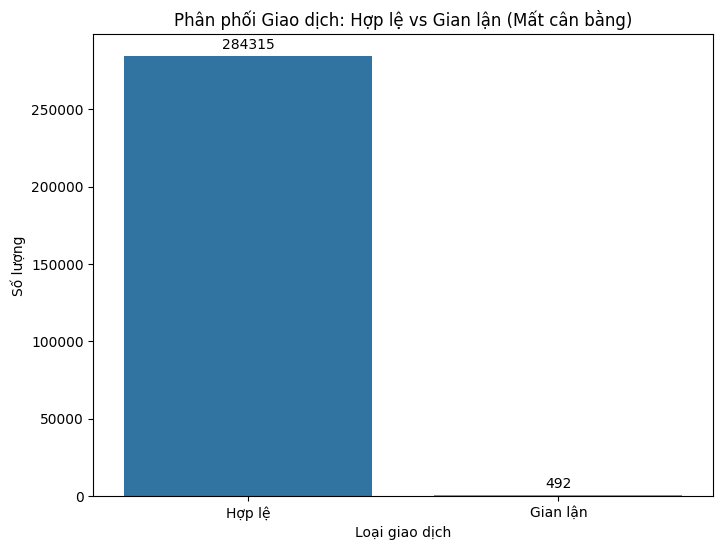

In [ ]:
# 1. Phân phối lớp
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Class', data=df, hue='Class', palette='tab10', legend=False)
plt.title('Phân phối Giao dịch: Hợp lệ vs Gian lận (Mất cân bằng)')
plt.xticks([0, 1], ['Hợp lệ', 'Gian lận'])
plt.xlabel('Loại giao dịch')
plt.ylabel('Số lượng')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
plt.show()

**Quan sát**: Trong tổng số 284,807 giao dịch, chỉ có 492 giao dịch gian lận (0.173%). Khoảng cách giữa hai lớp là cực lớn (gấp hơn 570 lần).

**Phân tích**: Đây là bài toán Imbalanced Classification điển hình. Nếu dùng độ chính xác (Accuracy), mô hình chỉ cần dự đoán mọi giao dịch là "hợp lệ" là đã đạt 99.8%, nhưng thực tế hệ thống sẽ hoàn toàn vô dụng vì bỏ sót toàn bộ gian lận.

**-->** Bắt buộc phải sử dụng các kỹ thuật cân bằng dữ liệu (như SMOTE) và thay đổi hệ chỉ số đánh giá sang Precision, Recall và F1-Score.

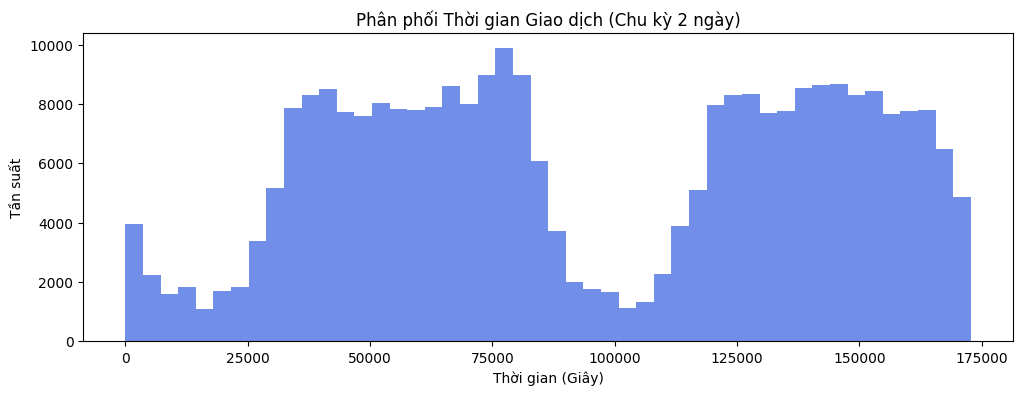

In [ ]:
# 2. Phân phối thời gian
plt.figure(figsize=(12,4))
sns.histplot(df['Time'], bins=48, kde=False, color='royalblue', edgecolor='none')
plt.title('Phân phối Thời gian Giao dịch (Chu kỳ 2 ngày)')
plt.xlabel('Thời gian (Giây)')
plt.ylabel('Tần suất')
plt.show()

**Quan sát**: Biểu đồ có hai "đỉnh" và hai "thung lũng" rõ rệt theo chu kỳ 24 giờ. Các khoảng sụt giảm giao dịch mạnh nhất rơi vào khoảng thời gian nghỉ ngơi (đêm khuya theo giờ địa phương của dataset).

**Phân tích**: Hành vi giao dịch của con người có tính chu kỳ. Gian lận có thể xảy ra bất cứ lúc nào, nhưng thường có xu hướng gia tăng vào các khung giờ ít người kiểm soát.

**-->** Đặc trưng Time cần được chuẩn hóa. Tuy nhiên, vì nó có tính tuần hoàn, việc sử dụng RobustScaler là bước khởi đầu tốt để thu hẹp khoảng cách giữa các khung giờ mà không phá vỡ quy luật phân phối.

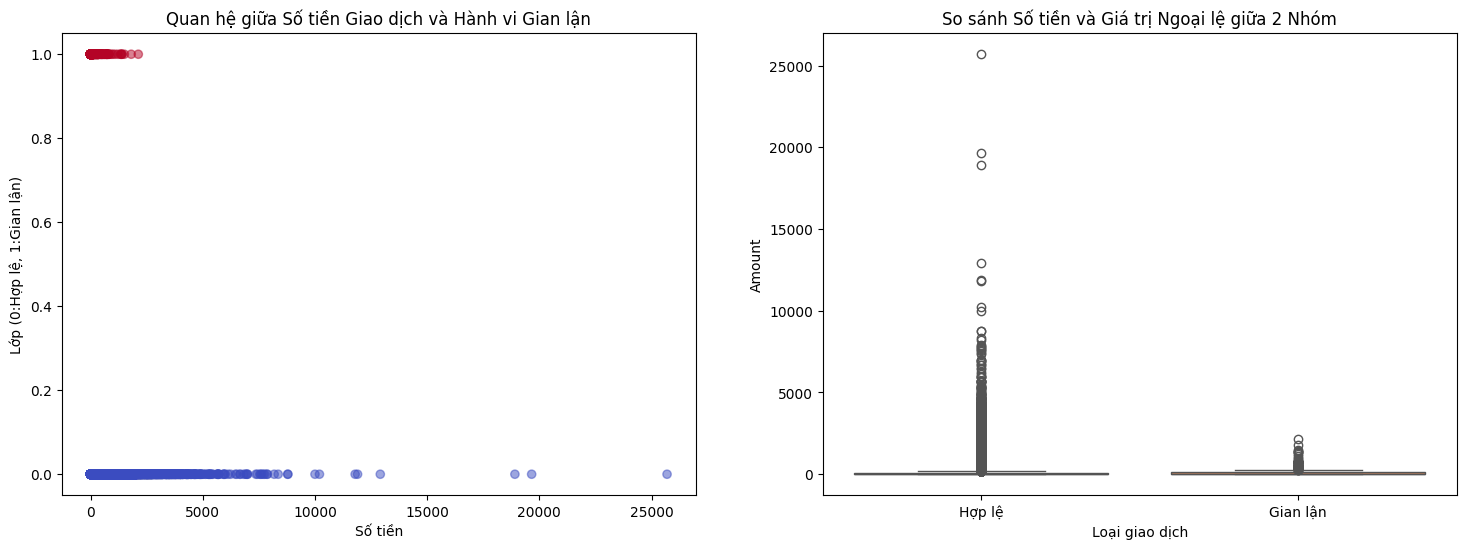

In [ ]:
# 3. Phân tích Số tiền theo Lớp
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].scatter(df['Amount'], df['Class'], alpha=0.5, c=df['Class'], cmap='coolwarm')
ax[0].set_title('Quan hệ giữa Số tiền Giao dịch và Hành vi Gian lận')
ax[0].set_xlabel('Số tiền')
ax[0].set_ylabel('Lớp (0:Hợp lệ, 1:Gian lận)')

sns.boxplot(x='Class', y='Amount', data=df, hue='Class', palette='muted', legend=False, ax=ax[1])
ax[1].set_title('So sánh Số tiền và Giá trị Ngoại lệ giữa 2 Nhóm')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Hợp lệ', 'Gian lận'])
ax[1].set_xlabel('Loại giao dịch')
plt.show()

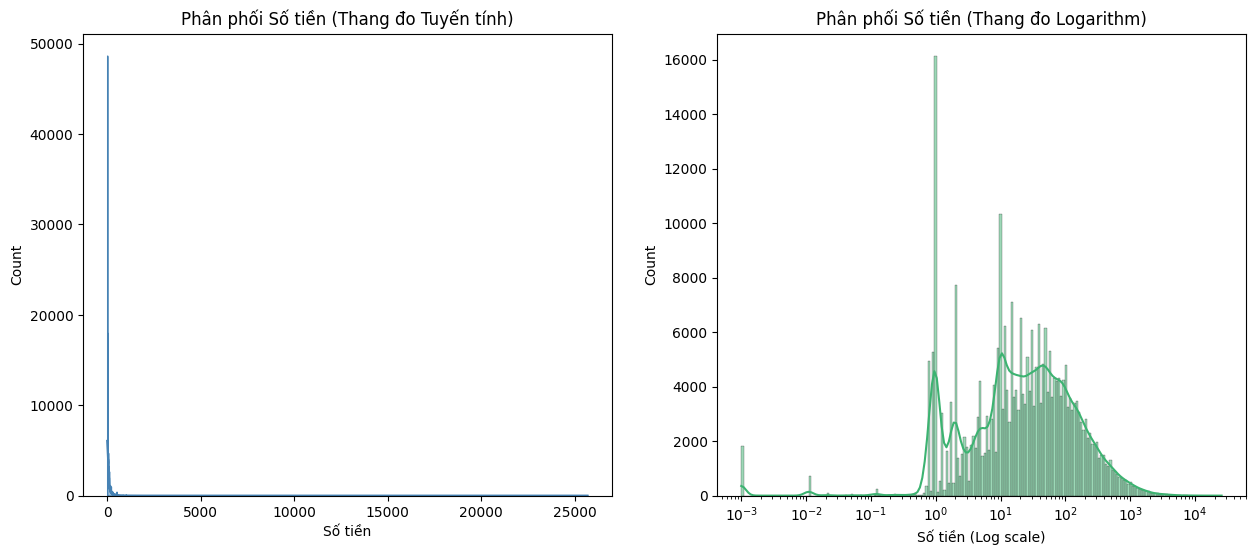

In [ ]:
# 4. Phân phối Số tiền (Linear & Log)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df['Amount'], kde=True, color='steelblue', ax=ax1, element='step')
ax1.set_title('Phân phối Số tiền (Thang đo Tuyến tính)')
ax1.set_xlabel('Số tiền')

sns.histplot(df['Amount'] + 0.001, kde=True, color='mediumseagreen', log_scale=True, ax=ax2)
ax2.set_title('Phân phối Số tiền (Thang đo Logarithm)')
ax2.set_xlabel('Số tiền (Log scale)')
plt.show()

**Quan sát**: Phần lớn giao dịch tập trung ở phân khúc giá trị thấp (Trung vị ~88 Euro). Tuy nhiên, biểu đồ Boxplot và Scatter phản ánh sự hiện diện của các "siêu ngoại lệ" (Extreme Outliers) lên tới 25,000 Euro. Mật độ ngoại lệ phía trên là cực kỳ dày đặc.

**Phân tích**: Dữ liệu bị lệch phải (Right-skewed) ở mức độ nghiêm trọng. Sự chênh lệch quá lớn giữa 88 Euro và 25,000 Euro sẽ khiến các mô hình nhạy cảm với khoảng cách (như Logistic Regression, Neural Networks) bị nhiễu hoàn toàn, dẫn đến hiện tượng sai số hoặc làm mô hình mất khả năng hội tụ.

**-->** Nên ưu tiên sử dụng RobustScaler thay vì StandardScaler giúp mô hình "miễn nhiễm" với các giá trị cực đoan nhưng vẫn giữ lại được dấu vân tài chính của chúng, giúp việc bắt gian lận chính xác hơn mà không cần xóa bỏ Outliers.

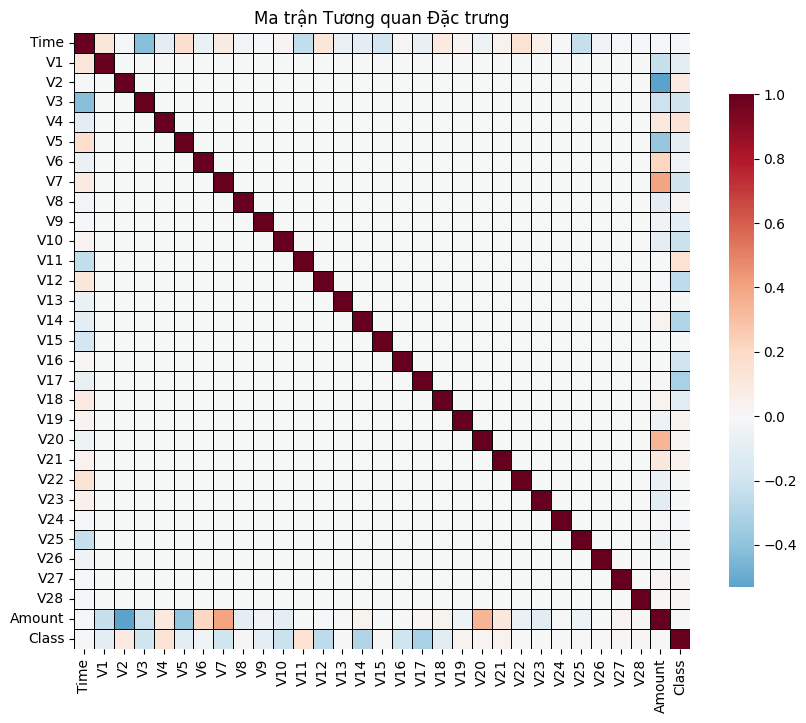


--- Top 10 đặc trưng tương quan mạnh nhất với Class ---
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447


In [ ]:
# 5. Ma trận tương quan
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, linewidths=.5, linecolor='black', square=True, cbar_kws={"shrink": .8})
plt.title('Ma trận Tương quan Đặc trưng')
plt.show()

print("\n--- Top 10 đặc trưng tương quan mạnh nhất với Class ---")
print(corr['Class'].abs().sort_values(ascending=False).head(10).to_string())

**Quan sát**: Các biến từ V1 đến V28 (đã PCA) không có tương quan với nhau (đúng tính chất PCA đã giúp khử tương quan dữ liệu gốc). Tuy nhiên, có những biến tương quan rất mạnh với cột Class (đặc biệt là V17, V14, V12 có tương quan âm mạnh; V4, V11 có tương quan dương).

**Phân tích**: Những biến này chứa đựng "dấu vân tay" của hành vi gian lận. Ví dụ: Khi giá trị V14 giảm sâu, xác suất đó là giao dịch gian lận sẽ tăng cao.

**-->** Cần đặc biệt chú ý đến độ quan trọng đặc trưng (Feature Importance) của các biến này ở bước Modeling để tối ưu hóa khả năng bắt gian lận.

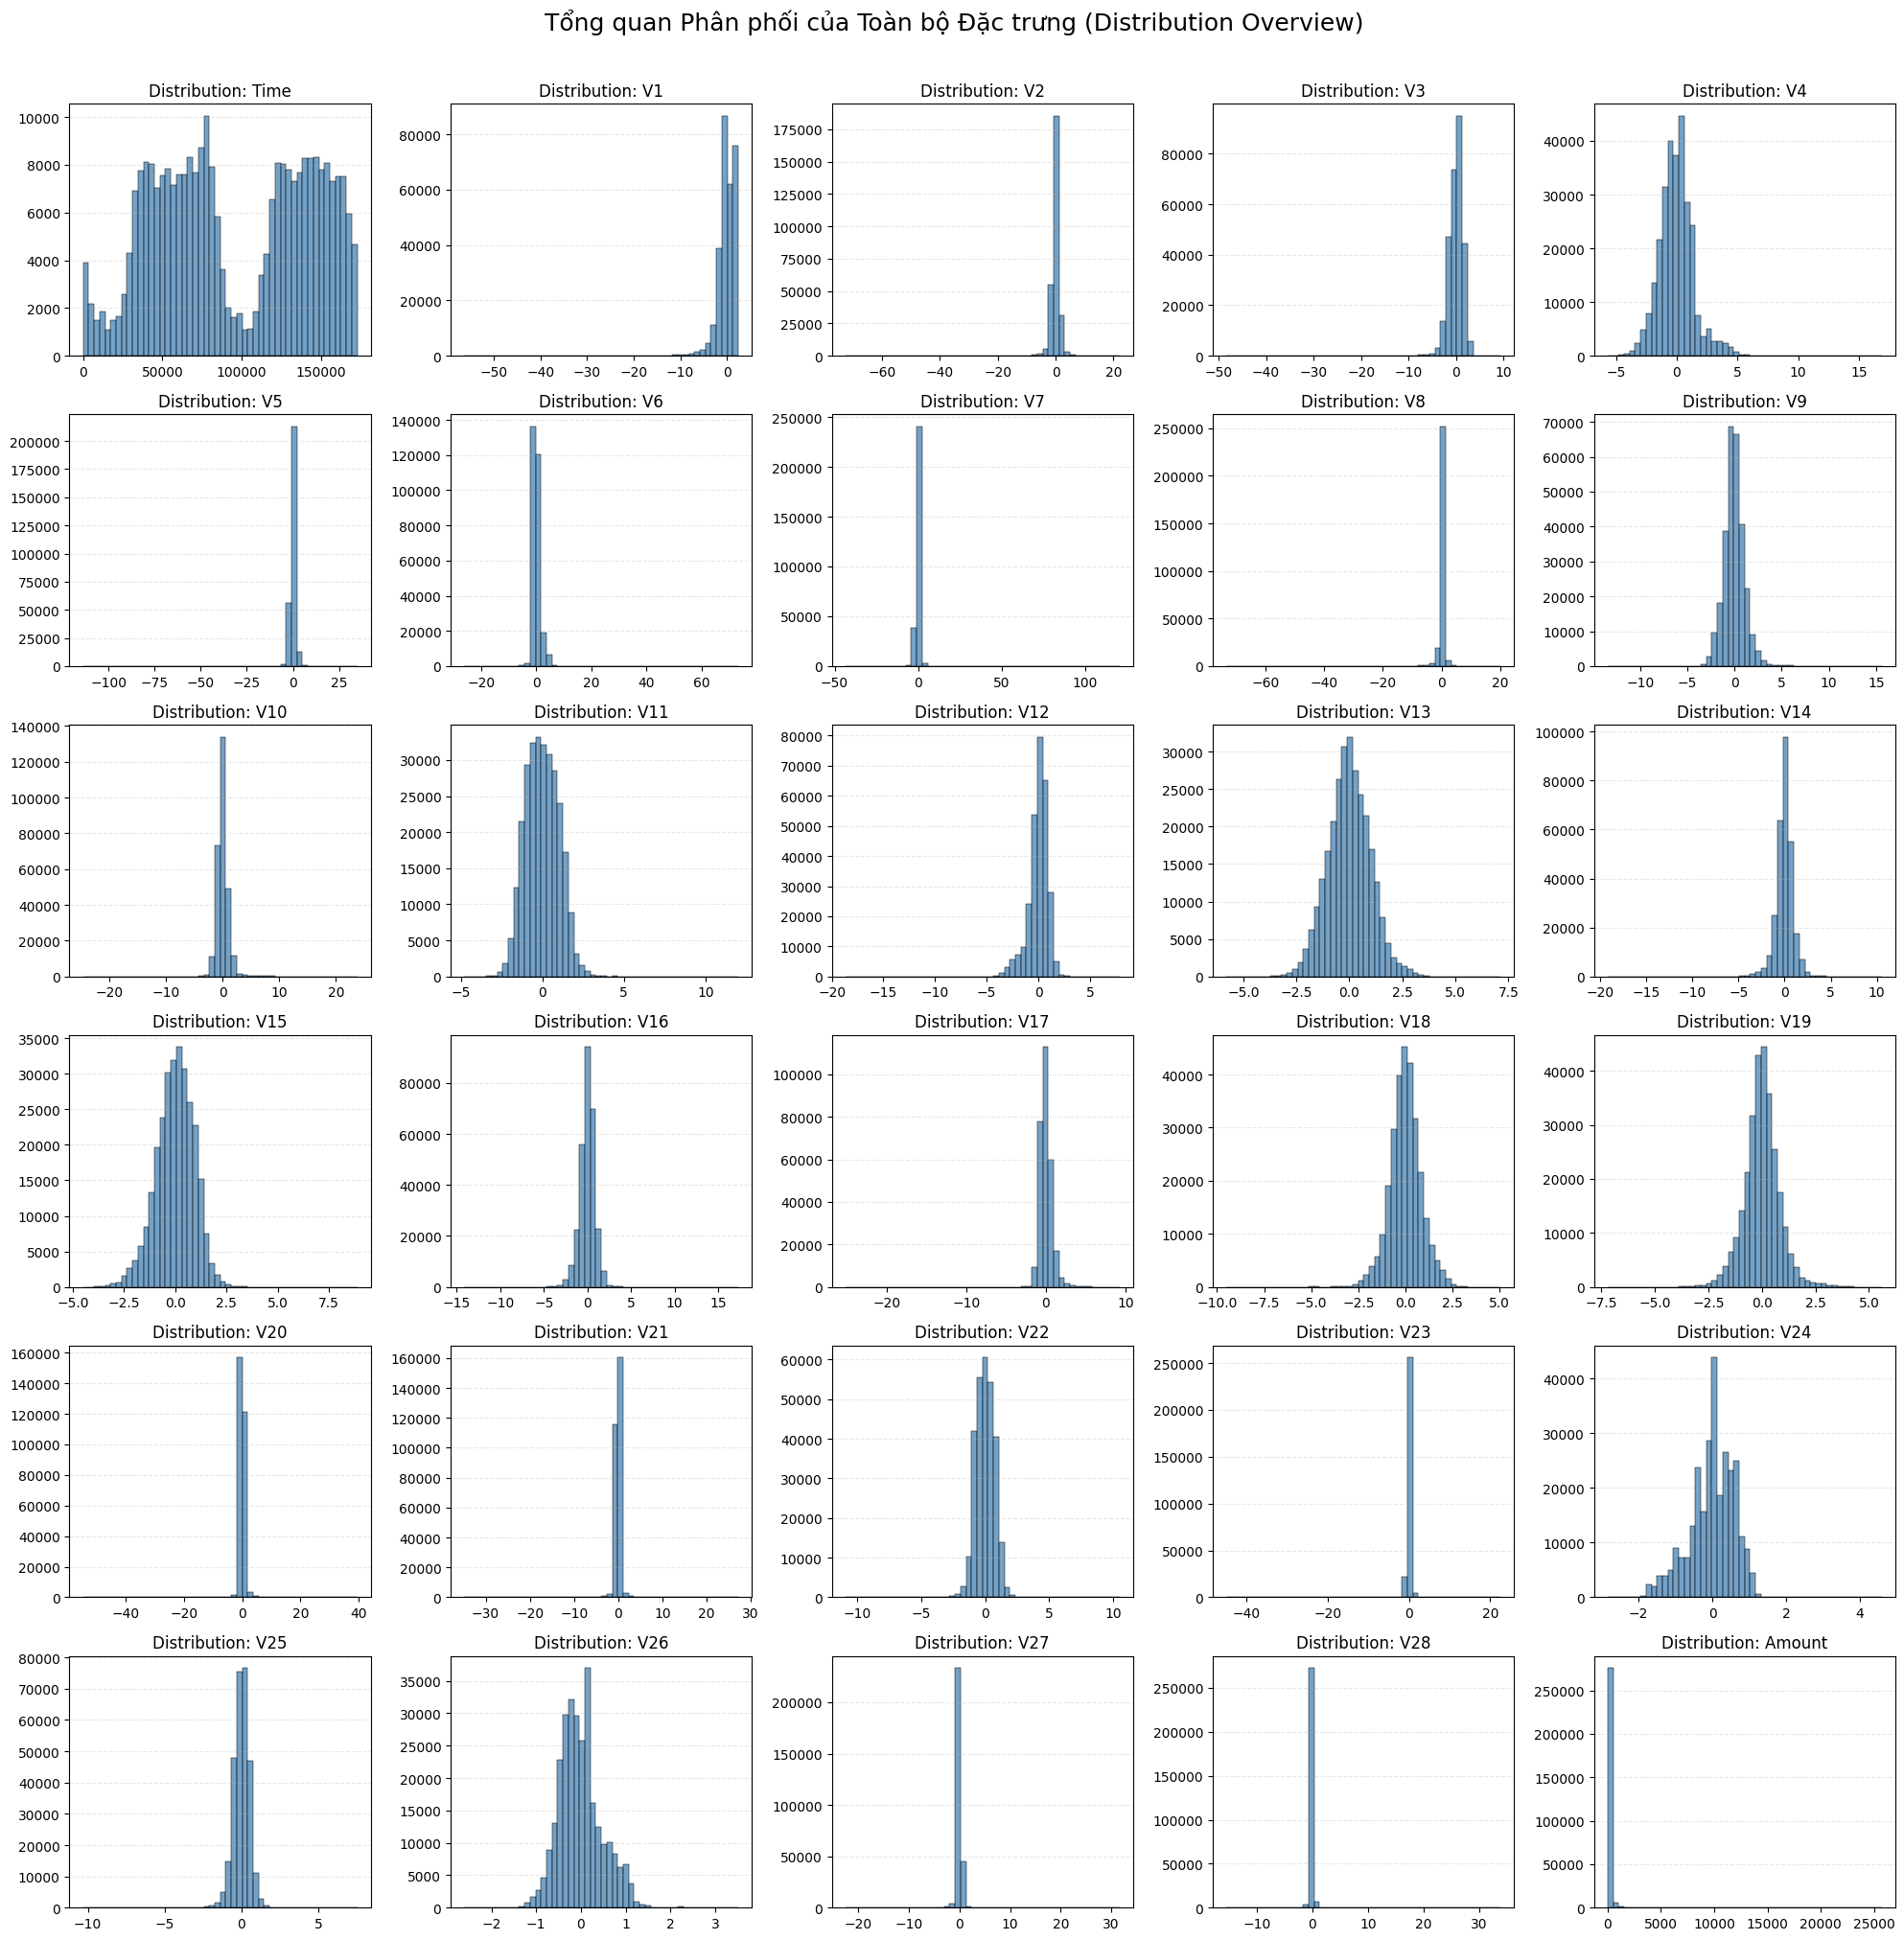

In [ ]:
# 6. Vẽ phân phối cho toàn bộ 30 đặc trưng
features = df.drop('Class', axis=1).columns
plt.figure(figsize=(20, 20))

for i, col in enumerate(features):
    plt.subplot(6, 5, i + 1)
    sns.histplot(df[col], kde=False, color='steelblue', bins=50)
    plt.title(f'Distribution: {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Tổng quan Phân phối của Toàn bộ Đặc trưng (Distribution Overview)', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

**Nhận xét**:
- Nhóm V1 - V28: Hầu hết đều có dạng phân phối hình chuông (đối xứng) và tập trung quanh giá trị 0. Điều này chứng tỏ thuật toán PCA đã làm rất tốt việc chuẩn hóa dữ liệu gốc, đưa chúng về một trạng thái khá "sạch" và ổn định.
- Đặc trưng Time (Thời gian): Phân phối có dạng hai đỉnh rõ rệt. Hai đỉnh này đại diện cho lưu lượng giao dịch trong hai ngày liên tiếp, với các khoảng trũng chính là thời điểm đêm khuya khi số lượng giao dịch giảm xuống.
- Đặc trưng Amount (Số tiền): Đây là biến số có phân phối lệch phải cực hạn. Có thể thấy hầu hết dữ liệu bị nén thành một cột cao vút ở sát vạch 0, trong khi trục hoành kéo dài tận hơn 25,000. Điều này minh chứng cho sự tồn tại của các giao dịch giá trị lớn (Outliers) và sự chênh lệch khủng khiếp về độ lớn so với các biến V.

**-->** Biểu đồ này chỉ ra rằng trong khi 28 biến V đã sẵn sàng, thì Time và Amount chính là hai "điểm nóng" cần được xử lý đặc biệt để không gây nhiễu cho các thuật toán học máy ở bước sau.

In [ ]:
print("Thống kê mô tả Mean và Std của 28 biến PCA (V1-V28):")
V_columns = [col for col in df.columns if col.startswith('V')]
stats_V = df[V_columns].agg(['mean', 'std']).T

display(stats_V.describe().round(6))

print("\nKhoảng dao động của Độ lệch chuẩn (Std):")
display(stats_V['std'].agg(['min', 'max']).round(4))


Thống kê mô tả Mean và Std của 28 biến PCA (V1-V28):


,mean,std
count,28.0,28.000000
mean,0.0,0.976391
std,0.0,0.386740
min,-0.0,0.330083
25%,-0.0,0.732318
50%,0.0,0.936956
75%,0.0,1.205038
max,0.0,1.958696



Khoảng dao động của Độ lệch chuẩn (Std):


,std
min,0.3301
max,1.9587


**Nhận xét**: Thống kê mô tả cho thấy toàn bộ 28 đặc trưng PCA đều có trung bình (mean) xấp xỉ 0 và độ lệch chuẩn (std) dao động biên độ hẹp (0.33 đến 1.96). Điều đó cho thấy rằng dữ liệu gốc đã được chuẩn hóa nghiêm ngặt trước khi thực hiện thuật toán giảm chiều dữ liệu PCA. Do đó, các biến từ V1 đến V28 đã nằm trên cùng một hệ quy chiếu và hoàn toàn không cần áp dụng thêm bất kỳ kỹ thuật Scaling nào ở các bước tiếp theo.

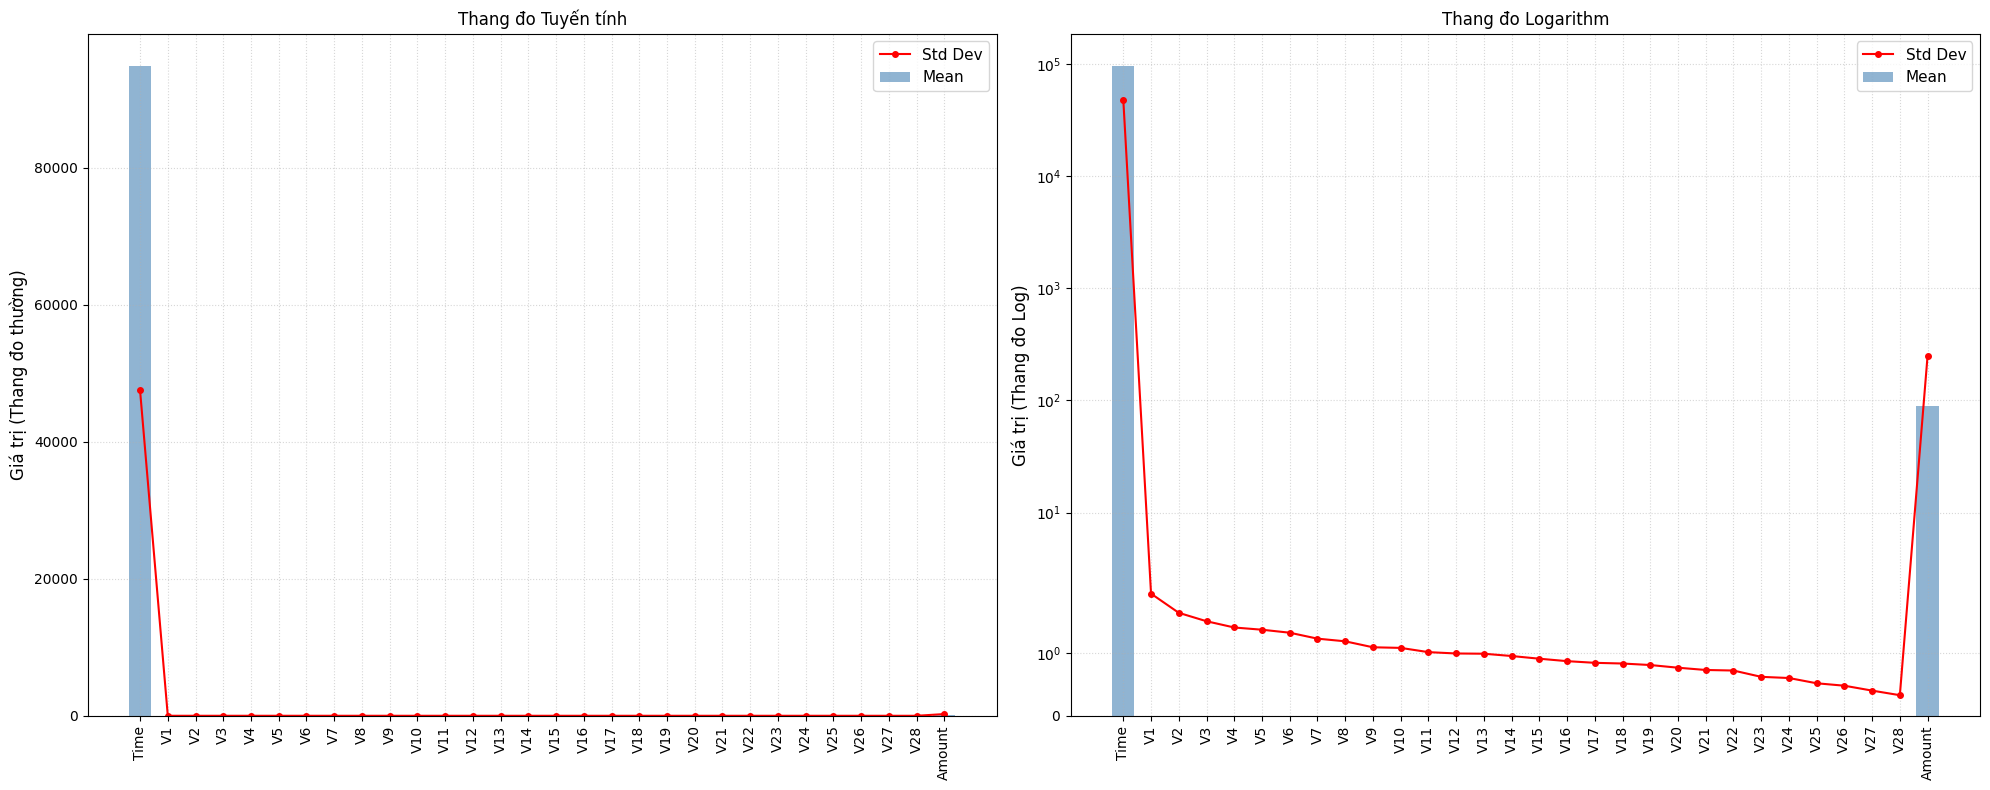

In [ ]:
# 7. Phân tích thang đo đặc trưng

stats = df.drop('Class', axis=1).agg(['mean', 'std']).T
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(20, 8))

ax_lin.bar(stats.index, stats['mean'], color='steelblue', alpha=0.6, label='Mean')
ax_lin.plot(stats.index, stats['std'], color='red', marker='o', markersize=4, label='Std Dev')
ax_lin.set_ylabel('Giá trị (Thang đo thường)', fontsize=12)
ax_lin.set_title('Thang đo Tuyến tính')
ax_lin.legend(fontsize=11)

ax_log.bar(stats.index, stats['mean'], color='steelblue', alpha=0.6, label='Mean')
ax_log.plot(stats.index, stats['std'], color='red', marker='o', markersize=4, label='Std Dev')
ax_log.set_yscale('symlog')
ax_log.set_ylabel('Giá trị (Thang đo Log)', fontsize=12)
ax_log.set_title('Thang đo Logarithm')
ax_log.legend(fontsize=11)

for ax in [ax_lin, ax_log]:
    ax.set_xticks(range(len(stats.index)))
    ax.set_xticklabels(stats.index, rotation=90, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Quan sát**:
- Thang Tuyến tính: Cột Time chiếm sóng hoàn toàn với giá trị lên đến hơn 170000, trong khi các biến V1-V28 và Amount bị nén xuống sát trục hoành, trông như bằng 0.
- Thang Logarithm: Khi đưa về thang Log, ta thấy các biến V1-V28 thực chất có sự biến thiên ổn định quanh mức 1-2, cột Amount cũng hiện rõ với độ lệch chuẩn đáng kể (khoảng 250).

**Phân tích**:
- Nhóm V1 - V28: là các biến đã qua thuật toán PCA để bảo mật và nén dữ liệu (được mô tả trong thông tin dataset). Vì PCA đã đưa chúng về cùng một hệ quy chiếu (Mean xấp xỉ 0), ta không cần can thiệp scaling thêm cho nhóm này.
- Các biến gốc như Time và Amount vốn có sai khác cực lớn về độ lớn đại lượng so với nhóm V1-V28, ta ưu tiên sử dụng RobustScaler dựa trên Trung vị (Median) và Khoảng biến thiên tứ phân vị (IQR) thay vì các phương pháp truyền thống như StandardScaler do tính kháng nhiễu vượt trội:
  - Đối với Amount (Số tiền): giúp kháng lại các giá trị ngoại lệ (Outliers). Dữ liệu Amount bị lệch rất mạnh và chứa nhiều giao dịch có giá trị cực lớn. Nếu dùng phương pháp truyền thống (StandardScaler), các giá trị lớn này sẽ kéo lệch giá trị trung bình, khiến cho đại đa số các giao dịch nhỏ khác bị nén bẹp lại và không còn sự khác biệt. RobustScaler giúp đảm bảo mô hình vẫn nhận diện tốt sự khác biệt giữa các giao dịch nhỏ.
  - Đối với Time (Thời gian): giúp bảo tảo toàn cấu trúc chu kỳ. Biến Time không tuân theo phân phối hình chuông (đều đặn) mà có các đỉnh cao và đáy thấp đại diện cho tính chu kỳ của ngày và đêm. Nếu ép nó vào phân phối chuẩn, chúng ta vô tình sẽ bóp méo hình dạng thực tế của các chu kỳ này. RobustScaler giúp thu nhỏ thang đo của Time về cùng cấp độ với các biến khác mà không làm thay đổi hình dáng phân phối tự nhiên. Điều này giúp mô hình giữ lại được các manh mối hành vi quan trọng theo thời gian (ví dụ: giao dịch vào 2h sáng có rủi ro khác với 2h chiều) thay vì bị gò ép vào một khuôn mẫu toán học xa rời thực tế.

**Kết luận**: Việc thực hiện Robust Scaling tập trung vào hai cột Time và Amount là rất cần thiết để đồng bộ hóa toàn bộ 30 đặc trưng về cùng một tầm giá trị. Từ đó tạo ra một đầu vào cân bằng, giúp các thuật toán (như Logistic Regression, SVM,...) tránh được hiện tượng thiên kiến (bias) đối với các đặc trưng có thang đo lớn, giúp đảm bảo quá trình huấn luyện diễn ra ổn định và mô hình hội tụ nhanh hơn.

---
**TIỀN XỬ LÝ DỮ LIỆU**: Sau khi đã hiểu rõ bản chất và các hành vi của các đặc trưng, ta bắt đầu tiến hành tiền xử lý dữ liệu. Quy trình này sẽ tuân thủ nghiêm ngặt các nguyên tắc sau để đảm bảo độ tin cậy của kết quả:
- Chia dữ liệu: Thực hiện chia tập dữ liệu Train/Test (80/20) trước khi tiến hành chuẩn hóa nhằm ngăn chặn hiện tượng Rò rỉ dữ liệu (Data Leakage). Đặc biệt, kỹ thuật lấy mẫu phân tầng stratify=y dựa trên cột Class đã được áp dụng để bảo toàn tỉ lệ giao dịch gian lận (0.17%) đồng nhất trên cả hai tập dữ liệu, từ đó đảm bảo quá trình huấn luyện và đánh giá mô hình sau này diễn ra khách quan và chính xác nhất.
- Chuẩn hóa dữ liệu (Feature Scaling): Áp dụng RobustScaler cho hai cột Time và Amount.
- Bảo toàn dữ liệu (Data Persistency): Lưu các tập dữ liệu đã xử lý cùng với bộ Scaler (scaler.pkl) để phục vụ cho các bước Modeling và Deployment sau này.
- Chưa thực hiện kỹ thuật SMOTE trong bước này vì:
  - Ngăn chặn rò rỉ dữ liệu trong Cross-Validation (CV): Việc áp dụng SMOTE trên toàn bộ tập train trước khi chia Fold sẽ gây ra hiện tượng Rò rỉ dữ liệu. Sẽ chỉ thực hiện SMOTE bên trong từng vòng lặp CV trên các Fold huấn luyện để đảm bảo tính khách quan tuyệt đối cho quá trình đánh giá.
  - Giữ độ thuần khiết cho tập Test: Ta cũng ko tiến hành SMOTE trên tập test để giữ cho tập dữ liệu Test là dữ liệu thật 100% giúp phản ánh đúng thực tế khi mô hình đi vào vận hành.
  - Thiết lập Baseline (Mốc so sánh): Việc giữ dữ liệu "sạch" và chưa cân bằng giúp ta đánh giá được hiệu quả thực tế của mô hình gốc (Baseline) trước khi quyết định can thiệp các chiến lược xử lý mất cân bằng phức tạp hơn.

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Đã chia tập dữ liệu: Train = {X_train_raw.shape[0]}, Test = {X_test_raw.shape[0]}")

print("\nTrain distribution:")
print(pd.concat([
    y_train.value_counts().sort_index(),
    y_train.value_counts(normalize=True).sort_index()
], axis=1, keys=["Count", "Ratio"]))

print("\n\nTest distribution:")
print(pd.concat([
    y_test.value_counts().sort_index(),
    y_test.value_counts(normalize=True).sort_index()
], axis=1, keys=["Count", "Ratio"]))

Đã chia tập dữ liệu: Train = 227845, Test = 56962

Train distribution:
        Count     Ratio
Class                  
0      227451  0.998271
1         394  0.001729


Test distribution:
       Count    Ratio
Class                
0      56864  0.99828
1         98  0.00172


In [ ]:
rob_scaler = RobustScaler()
train_scaled = rob_scaler.fit_transform(X_train_raw[['Amount', 'Time']])
test_scaled = rob_scaler.transform(X_test_raw[['Amount', 'Time']])

with open('modeling/scaler.pkl', 'wb') as f:
    pickle.dump(rob_scaler, f)
print("Đã lưu RobustScaler tại 'modeling/scaler.pkl'")

Đã lưu RobustScaler tại 'modeling/scaler.pkl'


In [ ]:
def finalize_df(df_raw, scaled_values):
    df_new = df_raw.copy()
    df_new['scaled_amount'] = scaled_values[:, 0]
    df_new['scaled_time'] = scaled_values[:, 1]
    df_new.drop(['Amount', 'Time'], axis=1, inplace=True)
    cols = ['scaled_amount', 'scaled_time'] + [c for c in df_new.columns if c not in ['scaled_amount', 'scaled_time']]
    return df_new[cols]

X_train = finalize_df(X_train_raw, train_scaled)
X_test = finalize_df(X_test_raw, test_scaled)

display(X_train.head())

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
265518,-0.204315,0.905774,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,...,-0.451365,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248
180305,-0.264579,0.465984,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,...,-0.274411,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002
42664,2.130828,-0.512286,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,...,0.004631,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340
198723,-0.221294,0.561678,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,...,0.257424,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005
82325,0.892136,-0.298886,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,...,-0.082746,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194


In [ ]:
X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False, header=True)
y_test.to_csv('data/processed/y_test.csv', index=False, header=True)

with open('data/processed/data_splits.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }, f)

print("Dữ liệu đã sẵn sàng cho bước Modeling.")

Dữ liệu đã sẵn sàng cho bước Modeling.


HÀM HỖ TRỢ:

In [ ]:
from sklearn.metrics import fbeta_score, make_scorer

def f1_score(y_true, y_pred):
    # Hàm tính F1-Score (ưu tiên Recall và Precision ngang nhau)
    return fbeta_score(y_true, y_pred, beta=1, zero_division=0)

def f2_score(y_true, y_pred):
    # Hàm tính F2-Score (Ưu tiên Recall gấp đôi Precision)
    return fbeta_score(y_true, y_pred, beta=2, zero_division=0)

Định nghĩa Kiến trúc Mô hình Tùy chỉnh (custom xgboost)

In [ ]:
import xgboost as xgb
from sklearn.base import BaseEstimator, ClassifierMixin

# ĐỊNH NGHĨA MÔ HÌNH FOCAL LOSS ĐƠN LẺ
class FocalXGB(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0.9, gamma=1.25, max_depth=6, learning_rate=0.1, n_estimators=100, threshold=0.5):
        self.alpha = alpha
        self.gamma = gamma
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.threshold = threshold

    def _focal_loss_obj(self, predt, dtrain):
        label = dtrain.get_label()
        p = 1.0 / (1.0 + np.exp(-predt))
        p = np.clip(p, 1e-6, 1.0 - 1e-6)
        p_t = np.where(label == 1, p, 1 - p)
        alpha_t = np.where(label == 1, self.alpha, 1 - self.alpha)
        weight = self.alpha * (p**self.gamma) + (1-self.alpha) * ((1-p)**self.gamma)
        grad = weight * (p-label)
        hess = weight * p*(1-p)
        hess = np.maximum(hess, 1e-6)
        return grad, hess

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        dtrain = xgb.DMatrix(X, label=y)
        params = {
            'max_depth': self.max_depth,
            'eta': self.learning_rate,
            'verbosity': 0
        }
        self.model = xgb.train(params, dtrain, num_boost_round=self.n_estimators, obj=self._focal_loss_obj)
        return self

    def predict_proba(self, X):
        dtest = xgb.DMatrix(X)
        raw_preds = self.model.predict(dtest)
        proba = 1.0 / (1.0 + np.exp(-raw_preds))
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)


# ĐỊNH NGHĨA MÔ HÌNH SELF-ENSEMBLE
class FocalEnsembleXGB(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0.9, gamma_wide=1.0, gamma_deep=2.0, ensemble_weight=0.5, max_depth=6, learning_rate=0.1, n_estimators=100, threshold=0.5):
        self.alpha = alpha
        self.gamma_wide = gamma_wide
        self.gamma_deep = gamma_deep
        self.ensemble_weight = ensemble_weight
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.threshold = threshold

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        # Tạo 2 model FocalXGB đơn lẻ
        self.model_wide = FocalXGB(alpha=self.alpha, gamma=self.gamma_wide, max_depth=self.max_depth, learning_rate=self.learning_rate, n_estimators=self.n_estimators)
        self.model_deep = FocalXGB(alpha=self.alpha, gamma=self.gamma_deep, max_depth=self.max_depth, learning_rate=self.learning_rate, n_estimators=self.n_estimators)

        self.model_wide.fit(X, y)
        self.model_deep.fit(X, y)
        return self

    def predict_proba(self, X):
        # Trung bình cộng xác suất (Soft Voting)
        p_wide = self.model_wide.predict_proba(X)[:, 1]
        p_deep = self.model_deep.predict_proba(X)[:, 1]
        w = self.ensemble_weight
        avg_proba = w*p_deep + (1-w)*p_wide
        return np.vstack([1 - avg_proba, avg_proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)


Class implement pipeline tối ưu hyperparameter và tuning threshold

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import f1_score, fbeta_score

class AutoTunerCV(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, param_distributions, n_splits=5, scoring="average_precision", threshold_metric="f1", n_iter=20, random_state=42, n_jobs=None):
        self.estimator = estimator
        self.param_distributions = param_distributions
        self.n_splits = n_splits
        self.scoring = scoring
        self.threshold_metric = threshold_metric
        self.n_iter = n_iter
        self.random_state = random_state
        self.n_jobs = n_jobs

    def _make_scorer(self, scoring):
        from sklearn.metrics import average_precision_score, roc_auc_score, log_loss, fbeta_score

        if callable(scoring):
            return scoring

        proba_scorers = {
            'average_precision': lambda y, p: average_precision_score(y, p),
            'roc_auc':           lambda y, p: roc_auc_score(y, p),
            'neg_log_loss':      lambda y, p: -log_loss(y, p),
        }

        if scoring in proba_scorers:
            metric_fn = proba_scorers[scoring]
            def _proba_scorer(estimator, X_val, y_val):
                proba = estimator.predict_proba(X_val)[:, 1]
                return metric_fn(y_val, proba)
            return _proba_scorer

        predict_scorers = {
            'f2': lambda y, pred: fbeta_score(y, pred, beta=2, zero_division=0),
        }

        if scoring in predict_scorers:
            metric_fn = predict_scorers[scoring]
            def _predict_scorer(estimator, X_val, y_val):
                pred = estimator.predict(X_val)
                return metric_fn(y_val, pred)
            return _predict_scorer

        return scoring

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        cv = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        base_model = clone(self.estimator)

        scoring = self._make_scorer(self.scoring)

        search = RandomizedSearchCV(
            base_model,
            param_distributions=self.param_distributions,
            n_iter=self.n_iter,
            scoring=scoring,
            cv=cv,
            refit=True, # Tự động train kết quả tốt nhất trên toàn bộ tập train
            random_state=self.random_state,
            n_jobs=self.n_jobs,
        )
        search.fit(X, y)

        self.best_params_ = search.best_params_
        self.model_ = search.best_estimator_

        cv_model = clone(self.model_)
        oof_pred = cross_val_predict(cv_model, X, y, cv=cv, method="predict_proba", n_jobs=self.n_jobs)[:, 1]

        self.calibrator_ = IsotonicRegression(out_of_bounds="clip")
        self.calibrator_.fit(oof_pred, y)
        oof_calibrated = self.calibrator_.predict(oof_pred)

        thresholds = np.linspace(0, 1, 200)
        best_score = -1
        best_threshold = 0.5

        for t in thresholds:
            preds = (oof_calibrated > t).astype(int)

            if callable(self.threshold_metric):
                score = self.threshold_metric(y, preds)
            elif self.threshold_metric == "f1":
                score = f1_score(y, preds)
            elif self.threshold_metric == "f2":
                score = fbeta_score(y, preds, beta=2.0)
            else:
                raise ValueError("Unsupported metric")

            if score > best_score:
                best_score = score
                best_threshold = t

        self.best_threshold_ = best_threshold

        return self

    def predict_proba(self, X):
        raw_prob = self.model_.predict_proba(X)[:, 1]
        calibrated_prob = self.calibrator_.predict(raw_prob)
        return np.vstack([1.0 - calibrated_prob, calibrated_prob]).T

    def predict(self, X):
        prob = self.predict_proba(X)[:, 1]
        return self.classes_[(prob > self.best_threshold_).astype(int)]

    def get_params_summary(self):
        return {
            "best_params": self.best_params_,
            "best_threshold": self.best_threshold_,
        }

# Bước 2: Thử nghiệm và So sánh các Mô hình

**Mục tiêu:** Tìm ra model tốt nhất bằng cách thử nghiệm **4 phương án** khác nhau.

| STT | Phương án | Xử lý mất cân bằng |
|---|---|---|
| 1 | Base Model (mặc định) | Không |
| 2 | SMOTE | SMOTE |
| 3 | scale_pos_weight / class_weight | Trọng số lớp |
| 4 | SMOTE + scale_pos_weight | Kết hợp cả hai |

**Metrics đánh giá:** Precision, Recall, F1-score, F2-score, AUPRC.

**Phương pháp:** StratifiedKFold Cross-Validation (k=5). Chỉ thao tác trên tập Train.


Import thư viện & Đọc dữ liệu

In [ ]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X = data['X_train']
y = data['y_train']

PHƯƠNG ÁN 1: Base Model


In [ ]:

results_kb1 = {}

models_kb1 = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

for name, model in models_kb1.items():
    print(f"\n{name}:")
    print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")

    fold_metrics = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        m = deepcopy(model)
        m.fit(X_tr, y_tr)

        pred = m.predict(X_val)
        proba = m.predict_proba(X_val)[:, 1]

        metrics = [
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred, zero_division=0),
            f1_score(y_val, pred, zero_division=0),
            f2_score(y_val, pred),
            average_precision_score(y_val, proba)
        ]
        fold_metrics.append(metrics)
        print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

    ans = np.mean(fold_metrics, axis=0)
    print('-' * 62)
    print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")

    results_kb1[name] = {
        'Recall': ans[1],
        'AUPRC': ans[4],
        'F1': ans[2],
        'F2': ans[3]
    }


Logistic Regression:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.9057    | 0.6154   | 0.7328   | 0.6575   | 0.8144  
Fold 2  | 0.9216    | 0.5949   | 0.7231   | 0.6403   | 0.7561  
Fold 3  | 0.8462    | 0.6962   | 0.7639   | 0.7218   | 0.6983  
Fold 4  | 0.8475    | 0.6329   | 0.7246   | 0.6667   | 0.8016  
Fold 5  | 0.8772    | 0.6329   | 0.7353   | 0.6702   | 0.7354  
--------------------------------------------------------------
Average | 0.8796    | 0.6345   | 0.7359   | 0.6713   | 0.7612  


Decision Tree:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.7692    | 0.7692   | 0.7692   | 0.7692   | 0.5921  
Fold 2  | 0.8194    | 0.7468   | 0.7815   | 0.7603   | 0.6124  
Fold 3  | 0.8108    | 0.7595   | 0.7843   | 0.7692   | 0.6162  
Fold 4  | 0.6701    | 0.8228   | 0.7386   | 0.7869   | 0.5517  
Fold 5  | 0.7973    | 0.7468   | 0.7712   | 0.7564   | 0.5959  
--------------------------------------------------------------
Ave

#### Biểu đồ So sánh Models Phương án 1


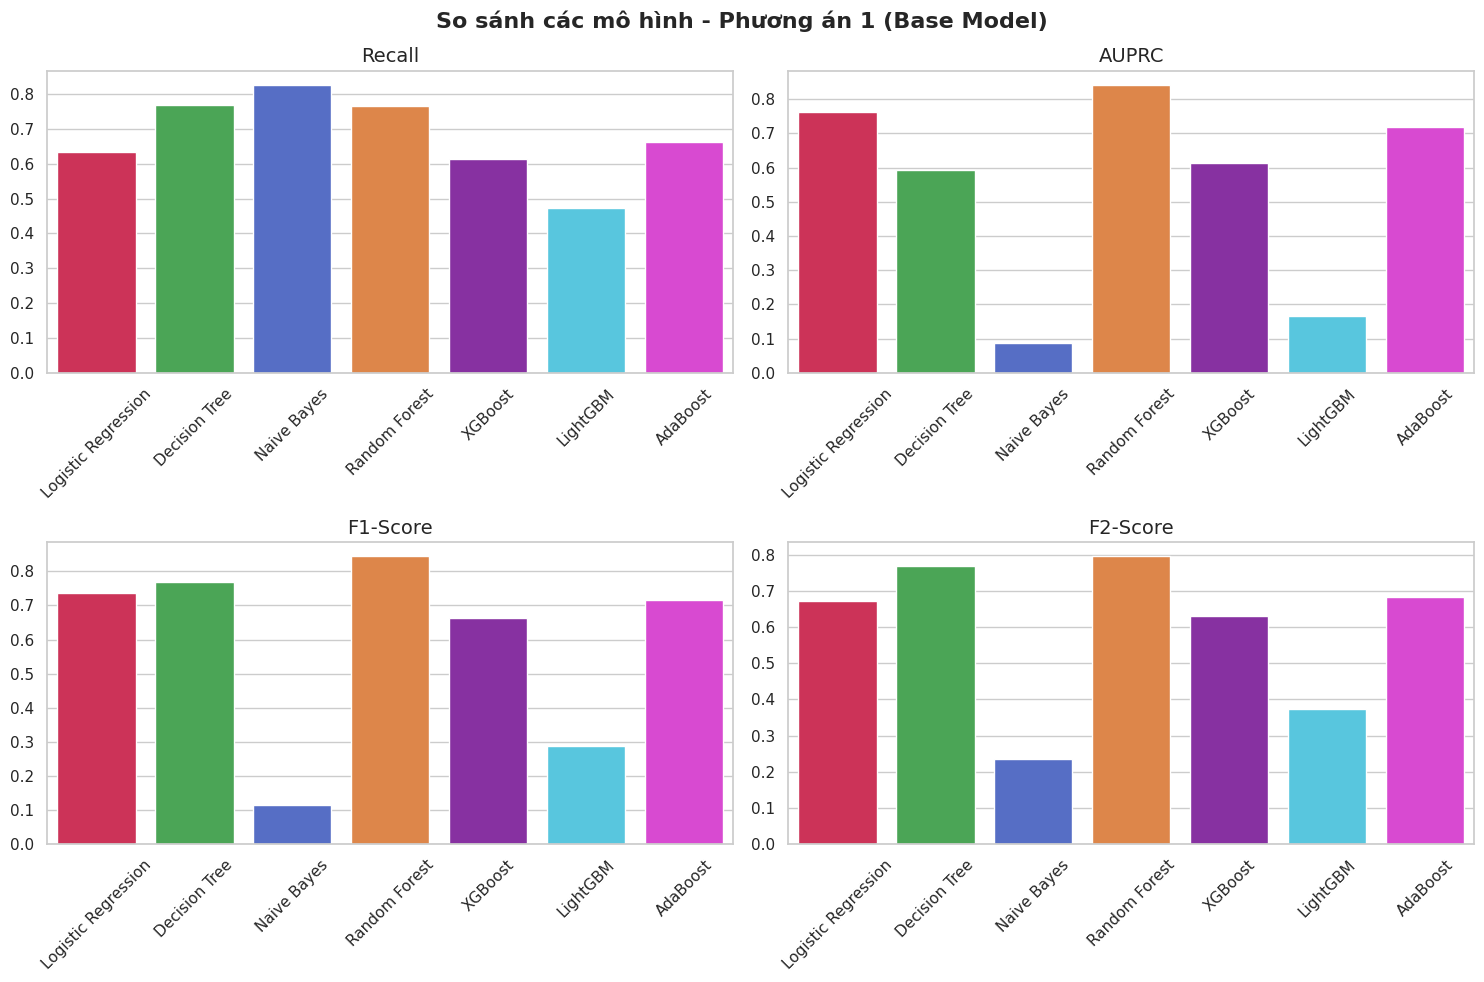

In [ ]:
models = list(results_kb1.keys())
recall_scores = [results_kb1[m]['Recall'] for m in models]
auprc_scores = [results_kb1[m]['AUPRC'] for m in models]
f1_scores = [results_kb1[m]['F1'] for m in models]
f2_scores = [results_kb1[m]['F2'] for m in models]

model_colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6']
palette = {m: model_colors[i] for i, m in enumerate(models)}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('So sánh các mô hình - Phương án 1 (Base Model)', fontsize=16, fontweight='bold')

# Vẽ Recall
sns.barplot(x=models, y=recall_scores, ax=axes[0, 0], palette=palette, hue=models, legend=False)
axes[0, 0].set_title('Recall', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Vẽ AUPRC
sns.barplot(x=models, y=auprc_scores, ax=axes[0, 1], palette=palette, hue=models, legend=False)
axes[0, 1].set_title('AUPRC', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# Vẽ F1-score
sns.barplot(x=models, y=f1_scores, ax=axes[1, 0], palette=palette, hue=models, legend=False)
axes[1, 0].set_title('F1-Score', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Vẽ F2-score
sns.barplot(x=models, y=f2_scores, ax=axes[1, 1], palette=palette, hue=models, legend=False)
axes[1, 1].set_title('F2-Score', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


PHƯƠNG ÁN 2: SMOTE

#### TH1: SMOTE ratio=1.0


In [ ]:
results_kb2_th1 = {}

models_kb2_th1 = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

for name, model in models_kb2_th1.items():
    print(f"\n{name}:")
    print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")

    fold_metrics = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        sm = SMOTE(sampling_strategy=1.0, random_state=42)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        m = deepcopy(model)
        m.fit(X_tr, y_tr)

        pred = m.predict(X_val)
        proba = m.predict_proba(X_val)[:, 1]

        metrics = [
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred, zero_division=0),
            f1_score(y_val, pred, zero_division=0),
            f2_score(y_val, pred),
            average_precision_score(y_val, proba)
        ]
        fold_metrics.append(metrics)
        print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

    ans = np.mean(fold_metrics, axis=0)
    print('-' * 62)
    print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")

    results_kb2_th1[name] = {
        'Recall': ans[1],
        'AUPRC': ans[4],
        'F1': ans[2],
        'F2': ans[3]
    }



Logistic Regression:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.0567    | 0.9359   | 0.1069   | 0.2281   | 0.7950  
Fold 2  | 0.0660    | 0.9114   | 0.1231   | 0.2559   | 0.7402  
Fold 3  | 0.0617    | 0.8861   | 0.1153   | 0.2412   | 0.6819  
Fold 4  | 0.0552    | 0.9367   | 0.1043   | 0.2234   | 0.7997  
Fold 5  | 0.0596    | 0.9241   | 0.1120   | 0.2369   | 0.7164  
--------------------------------------------------------------
Average | 0.0598    | 0.9188   | 0.1123   | 0.2371   | 0.7466  


Decision Tree:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.3135    | 0.7436   | 0.4411   | 0.5835   | 0.2336  
Fold 2  | 0.4240    | 0.6709   | 0.5196   | 0.6009   | 0.2850  
Fold 3  | 0.3654    | 0.7215   | 0.4851   | 0.6038   | 0.2641  
Fold 4  | 0.3580    | 0.7975   | 0.4941   | 0.6402   | 0.2858  
Fold 5  | 0.4248    | 0.8228   | 0.5603   | 0.6930   | 0.3499  
--------------------------------------------------------------
Ave

#### Biểu đồ Phương án 2 - TH1


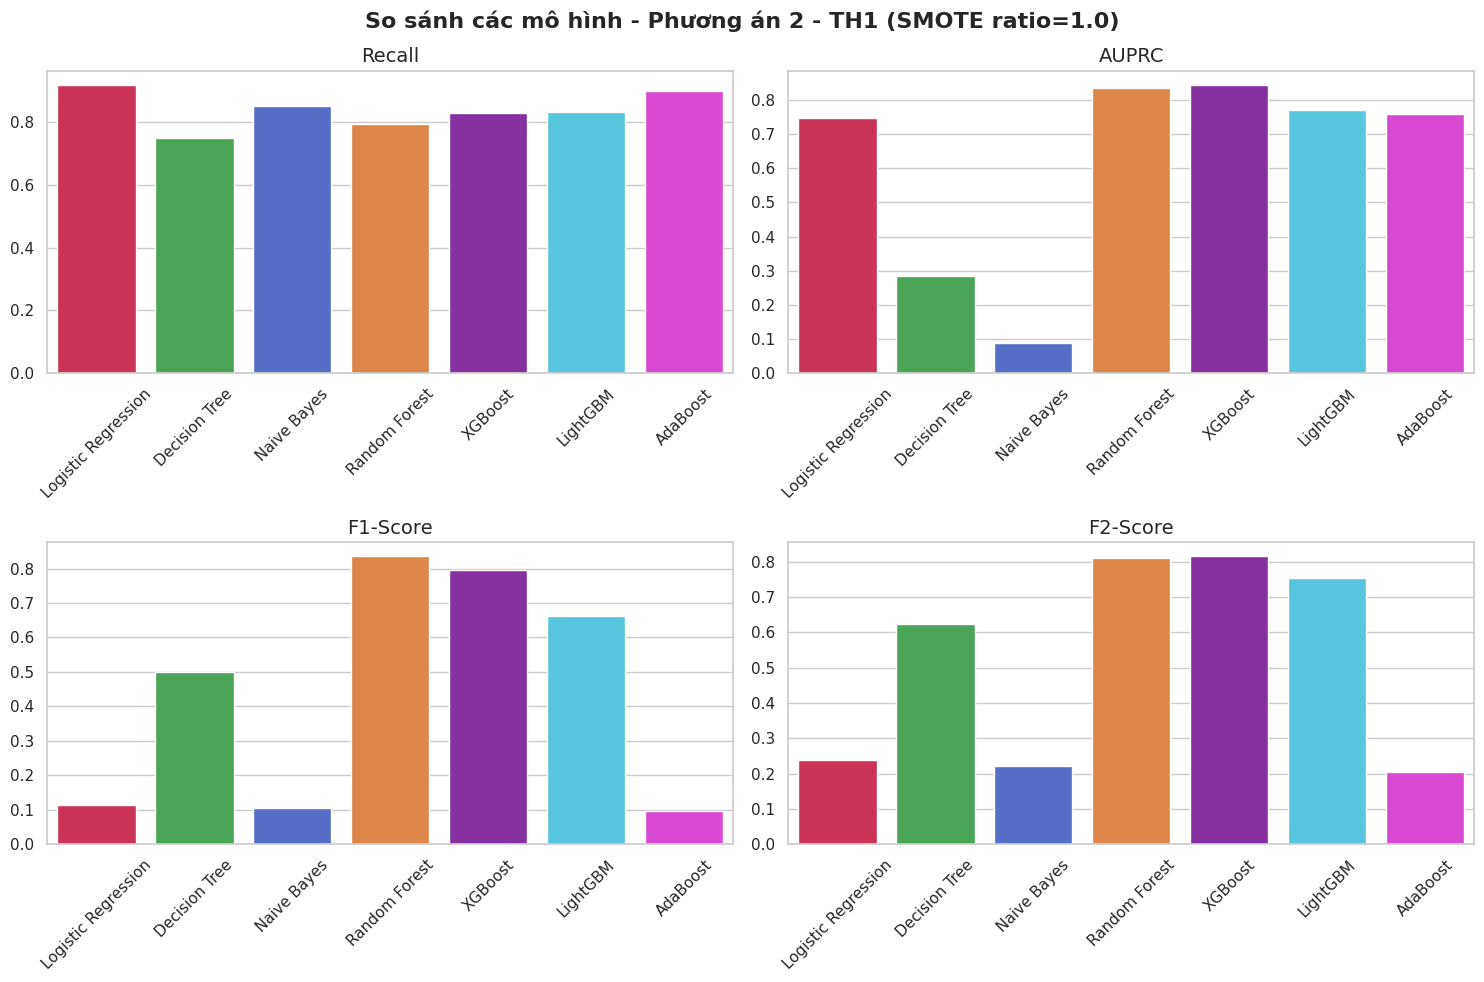

In [ ]:
models = list(results_kb2_th1.keys())
recall_scores = [results_kb2_th1[m]['Recall'] for m in models]
auprc_scores = [results_kb2_th1[m]['AUPRC'] for m in models]
f1_scores = [results_kb2_th1[m]['F1'] for m in models]
f2_scores = [results_kb2_th1[m]['F2'] for m in models]

model_colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6']
palette = {m: model_colors[i] for i, m in enumerate(models)}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('So sánh các mô hình - Phương án 2 - TH1 (SMOTE ratio=1.0)', fontsize=16, fontweight='bold')

# Vẽ Recall
sns.barplot(x=models, y=recall_scores, ax=axes[0, 0], palette=palette, hue=models, legend=False)
axes[0, 0].set_title('Recall', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Vẽ AUPRC
sns.barplot(x=models, y=auprc_scores, ax=axes[0, 1], palette=palette, hue=models, legend=False)
axes[0, 1].set_title('AUPRC', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# Vẽ F1-score
sns.barplot(x=models, y=f1_scores, ax=axes[1, 0], palette=palette, hue=models, legend=False)
axes[1, 0].set_title('F1-Score', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Vẽ F2-score
sns.barplot(x=models, y=f2_scores, ax=axes[1, 1], palette=palette, hue=models, legend=False)
axes[1, 1].set_title('F2-Score', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### TH2: SMOTE ratio=0.05


In [ ]:
results_kb2_th2 = {}

models_kb2_th2 = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

for name, model in models_kb2_th2.items():
    print(f"\n{name}:")
    print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")

    fold_metrics = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        sm = SMOTE(sampling_strategy=0.05, random_state=42)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        m = deepcopy(model)
        m.fit(X_tr, y_tr)

        pred = m.predict(X_val)
        proba = m.predict_proba(X_val)[:, 1]

        metrics = [
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred, zero_division=0),
            f1_score(y_val, pred, zero_division=0),
            f2_score(y_val, pred),
            average_precision_score(y_val, proba)
        ]
        fold_metrics.append(metrics)
        print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

    ans = np.mean(fold_metrics, axis=0)
    print('-' * 62)
    print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")

    results_kb2_th2[name] = {
        'Recall': ans[1],
        'AUPRC': ans[4],
        'F1': ans[2],
        'F2': ans[3]
    }



Logistic Regression:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.6226    | 0.8462   | 0.7174   | 0.7895   | 0.8082  
Fold 2  | 0.6000    | 0.7975   | 0.6848   | 0.7482   | 0.7617  
Fold 3  | 0.5614    | 0.8101   | 0.6632   | 0.7442   | 0.6964  
Fold 4  | 0.5520    | 0.8734   | 0.6765   | 0.7823   | 0.8016  
Fold 5  | 0.5963    | 0.8228   | 0.6915   | 0.7647   | 0.7386  
--------------------------------------------------------------
Average | 0.5865    | 0.8300   | 0.6867   | 0.7658   | 0.7613  


Random Forest:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.8873    | 0.8077   | 0.8456   | 0.8225   | 0.8459  
Fold 2  | 0.9231    | 0.7595   | 0.8333   | 0.7874   | 0.8270  
Fold 3  | 0.9104    | 0.7722   | 0.8356   | 0.7963   | 0.8271  
Fold 4  | 0.8519    | 0.8734   | 0.8625   | 0.8690   | 0.9004  
Fold 5  | 0.9143    | 0.8101   | 0.8591   | 0.8290   | 0.8415  
--------------------------------------------------------------
Ave

#### Biểu đồ Phương án 2 - TH2


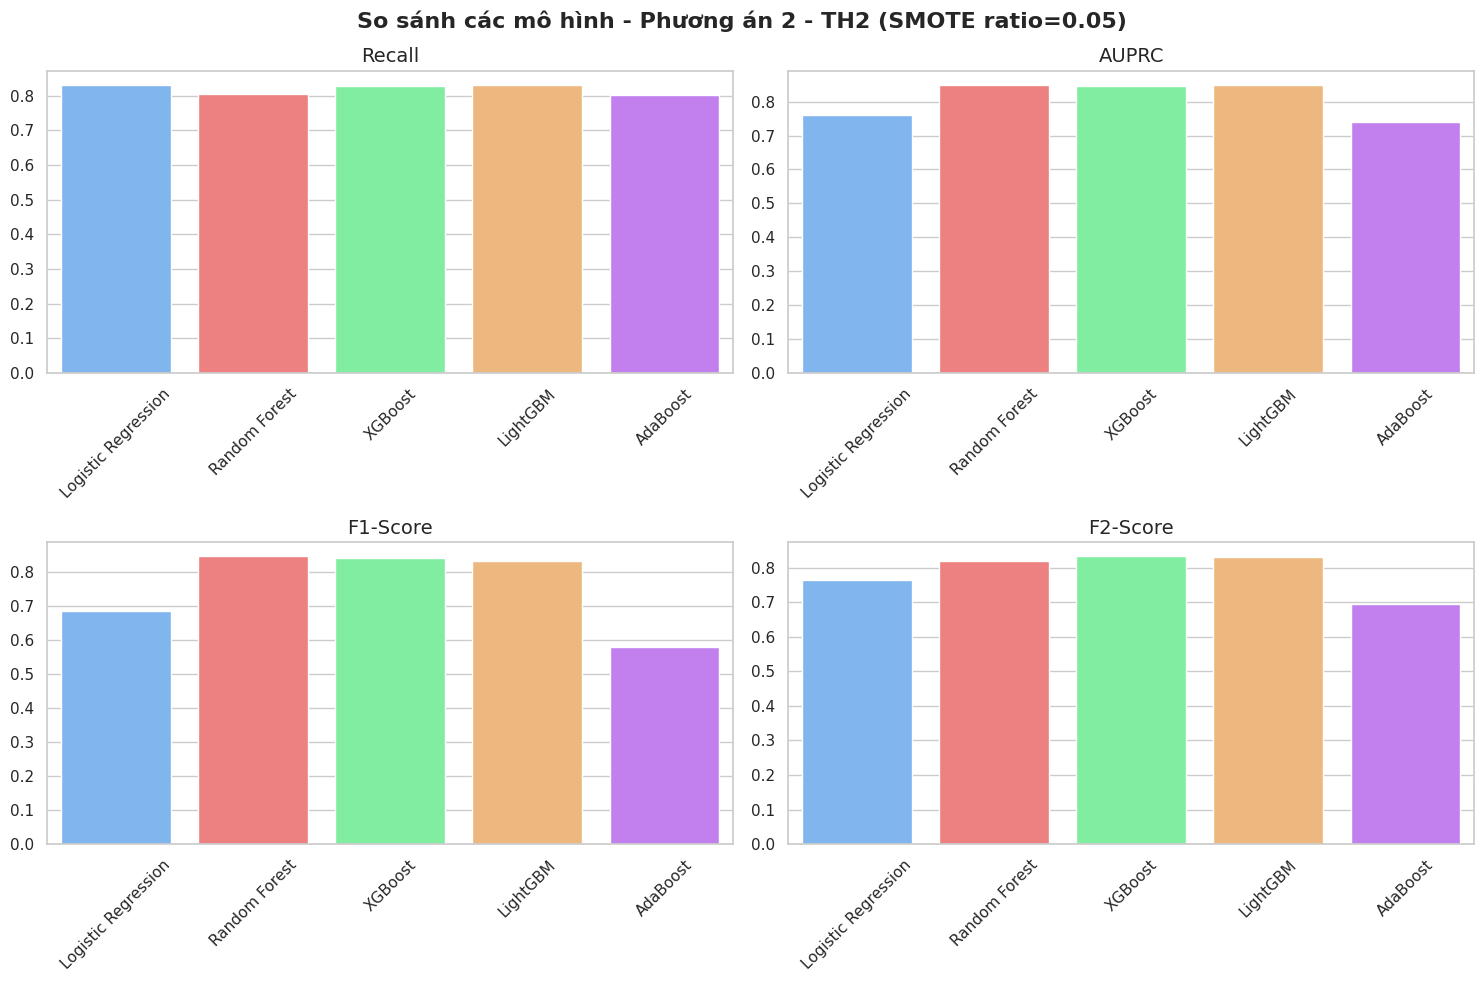

In [ ]:
models = list(results_kb2_th2.keys())
recall_scores = [results_kb2_th2[m]['Recall'] for m in models]
auprc_scores = [results_kb2_th2[m]['AUPRC'] for m in models]
f1_scores = [results_kb2_th2[m]['F1'] for m in models]
f2_scores = [results_kb2_th2[m]['F2'] for m in models]

model_colors = ['#6EB5FF', '#FF6E6E', '#6EFF9A', '#FFB86E', '#C46EFF']  # xanh dương, đỏ, xanh lá, cam, tím
palette = {m: model_colors[i] for i, m in enumerate(models)}
palette = {m: model_colors[i] for i, m in enumerate(models)}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('So sánh các mô hình - Phương án 2 - TH2 (SMOTE ratio=0.05)', fontsize=16, fontweight='bold')

# Vẽ Recall
sns.barplot(x=models, y=recall_scores, ax=axes[0, 0], palette=palette, hue=models, legend=False)
axes[0, 0].set_title('Recall', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Vẽ AUPRC
sns.barplot(x=models, y=auprc_scores, ax=axes[0, 1], palette=palette, hue=models, legend=False)
axes[0, 1].set_title('AUPRC', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# Vẽ F1-score
sns.barplot(x=models, y=f1_scores, ax=axes[1, 0], palette=palette, hue=models, legend=False)
axes[1, 0].set_title('F1-Score', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Vẽ F2-score
sns.barplot(x=models, y=f2_scores, ax=axes[1, 1], palette=palette, hue=models, legend=False)
axes[1, 1].set_title('F2-Score', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

PHƯƠNG ÁN 3: Class Weight / Scale Pos Weight

In [ ]:
results_kb3 = {}

models_kb3 = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

for name, model in models_kb3.items():
    print(f"\n{name}:")
    print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")

    fold_metrics = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        m = deepcopy(model)
        if name in ['XGBoost', 'LightGBM']:
            spw = y_tr.value_counts()[0] / y_tr.value_counts()[1]
            m.set_params(scale_pos_weight=spw)

        m.fit(X_tr, y_tr)

        pred = m.predict(X_val)
        proba = m.predict_proba(X_val)[:, 1]

        metrics = [
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred, zero_division=0),
            f1_score(y_val, pred, zero_division=0),
            f2_score(y_val, pred),
            average_precision_score(y_val, proba)
        ]
        fold_metrics.append(metrics)
        print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

    ans = np.mean(fold_metrics, axis=0)
    print('-' * 62)
    print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")

    results_kb3[name] = {
        'Recall': ans[1],
        'AUPRC': ans[4],
        'F1': ans[2],
        'F2': ans[3]
    }



Logistic Regression:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.0611    | 0.9359   | 0.1147   | 0.2422   | 0.7957  
Fold 2  | 0.0662    | 0.9114   | 0.1234   | 0.2564   | 0.7396  
Fold 3  | 0.0674    | 0.8734   | 0.1251   | 0.2575   | 0.6680  
Fold 4  | 0.0572    | 0.9367   | 0.1078   | 0.2298   | 0.8097  
Fold 5  | 0.0630    | 0.9114   | 0.1178   | 0.2467   | 0.7213  
--------------------------------------------------------------
Average | 0.0630    | 0.9138   | 0.1178   | 0.2465   | 0.7469  


Random Forest:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.9365    | 0.7564   | 0.8369   | 0.7867   | 0.8497  
Fold 2  | 1.0000    | 0.6962   | 0.8209   | 0.7412   | 0.8089  
Fold 3  | 0.9508    | 0.7342   | 0.8286   | 0.7692   | 0.8175  
Fold 4  | 0.9265    | 0.7975   | 0.8571   | 0.8203   | 0.8357  
Fold 5  | 0.9531    | 0.7722   | 0.8531   | 0.8026   | 0.8383  
--------------------------------------------------------------
Ave

#### Biểu đồ Phương án 3

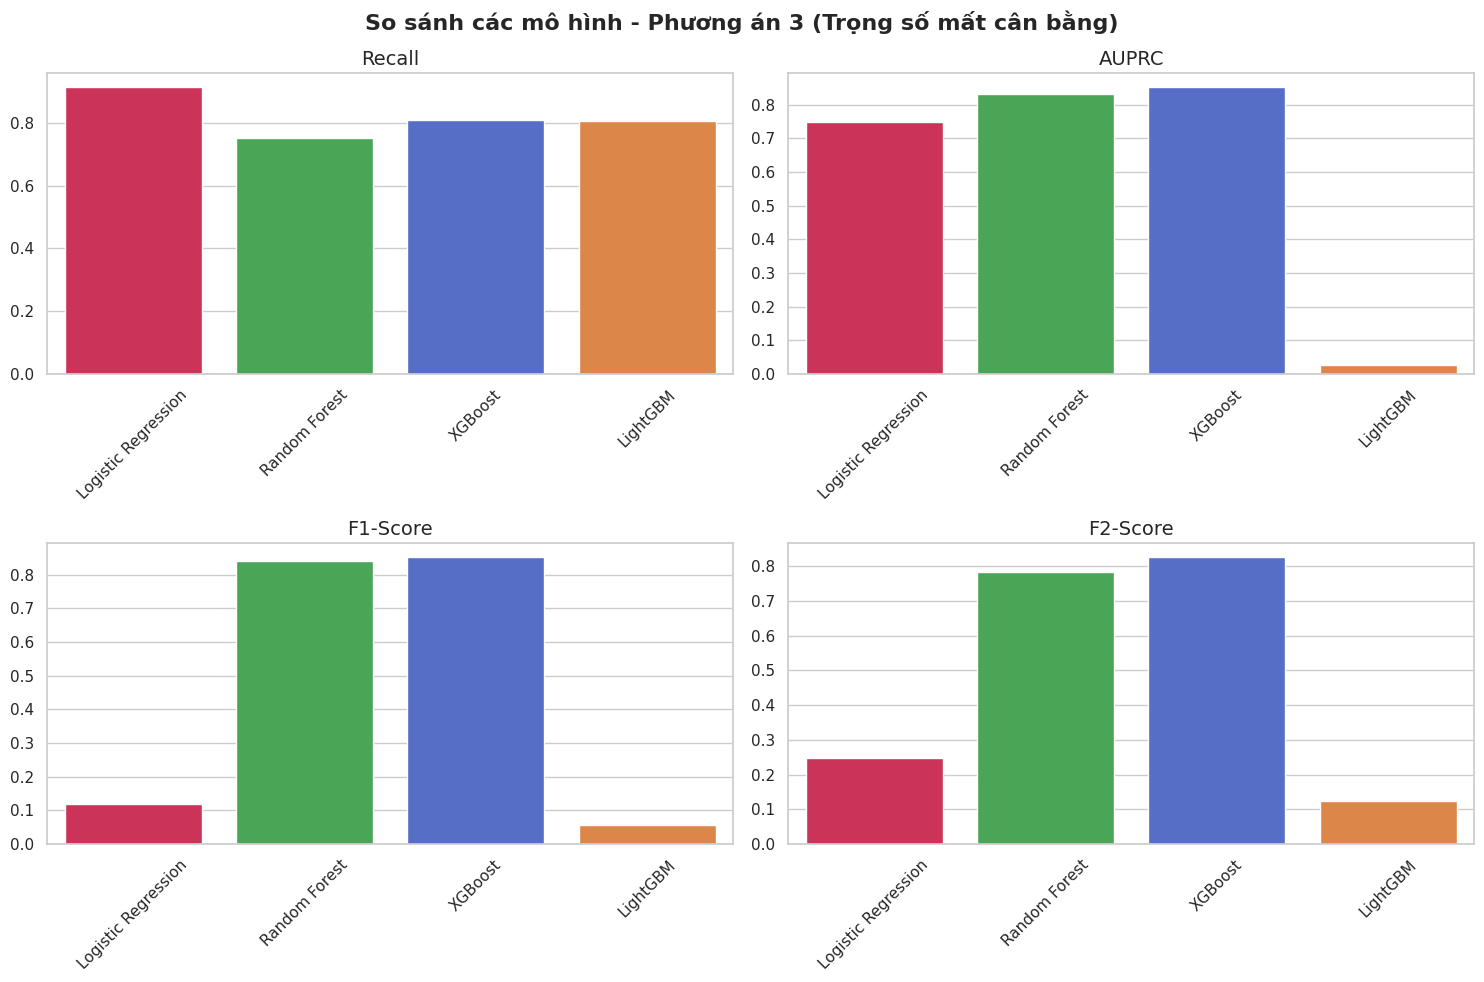

In [ ]:
models = list(results_kb3.keys())
recall_scores = [results_kb3[m]['Recall'] for m in models]
auprc_scores = [results_kb3[m]['AUPRC'] for m in models]
f1_scores = [results_kb3[m]['F1'] for m in models]
f2_scores = [results_kb3[m]['F2'] for m in models]

# 4 màu tương ứng đúng với 4 model
model_colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231']  # đỏ, lục, xanh, cam
palette = {m: model_colors[i] for i, m in enumerate(models)}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('So sánh các mô hình - Phương án 3 (Trọng số mất cân bằng)', fontsize=16, fontweight='bold')

# Vẽ Recall
sns.barplot(x=models, y=recall_scores, ax=axes[0, 0], palette=palette, hue=models, legend=False)
axes[0, 0].set_title('Recall', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Vẽ AUPRC
sns.barplot(x=models, y=auprc_scores, ax=axes[0, 1], palette=palette, hue=models, legend=False)
axes[0, 1].set_title('AUPRC', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# Vẽ F1-score
sns.barplot(x=models, y=f1_scores, ax=axes[1, 0], palette=palette, hue=models, legend=False)
axes[1, 0].set_title('F1-Score', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Vẽ F2-score
sns.barplot(x=models, y=f2_scores, ax=axes[1, 1], palette=palette, hue=models, legend=False)
axes[1, 1].set_title('F2-Score', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

PHƯƠNG ÁN 4: SMOTE + Class Weight


In [ ]:
results_kb4 = {}

models_kb4 = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

for name, model in models_kb4.items():
    print(f"\n{name}:")
    print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")

    fold_metrics = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        sm = SMOTE(sampling_strategy=0.05, random_state=42)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        m = deepcopy(model)
        if name in ['XGBoost', 'LightGBM']:
            spw = y_tr.value_counts()[0] / y_tr.value_counts()[1]
            m.set_params(scale_pos_weight=spw)

        m.fit(X_tr, y_tr)

        pred = m.predict(X_val)
        proba = m.predict_proba(X_val)[:, 1]

        metrics = [
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred, zero_division=0),
            f1_score(y_val, pred, zero_division=0),
            f2_score(y_val, pred),
            average_precision_score(y_val, proba)
        ]
        fold_metrics.append(metrics)
        print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

    ans = np.mean(fold_metrics, axis=0)
    print('-' * 62)
    print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")

    results_kb4[name] = {
        'Recall': ans[1],
        'AUPRC': ans[4],
        'F1': ans[2],
        'F2': ans[3]
    }



Logistic Regression:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.0571    | 0.9359   | 0.1076   | 0.2294   | 0.7919  
Fold 2  | 0.0632    | 0.9114   | 0.1181   | 0.2473   | 0.7382  
Fold 3  | 0.0603    | 0.8861   | 0.1129   | 0.2370   | 0.6792  
Fold 4  | 0.0557    | 0.9367   | 0.1051   | 0.2249   | 0.8014  
Fold 5  | 0.0580    | 0.9241   | 0.1091   | 0.2317   | 0.7181  
--------------------------------------------------------------
Average | 0.0588    | 0.9188   | 0.1106   | 0.2341   | 0.7458  


Random Forest:
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.8732    | 0.7949   | 0.8322   | 0.8094   | 0.8529  
Fold 2  | 0.9355    | 0.7342   | 0.8227   | 0.7672   | 0.8175  
Fold 3  | 0.9219    | 0.7468   | 0.8252   | 0.7763   | 0.8155  
Fold 4  | 0.8667    | 0.8228   | 0.8442   | 0.8312   | 0.8741  
Fold 5  | 0.9000    | 0.7975   | 0.8456   | 0.8161   | 0.8435  
--------------------------------------------------------------
Ave

#### Biểu đồ Phương án 4

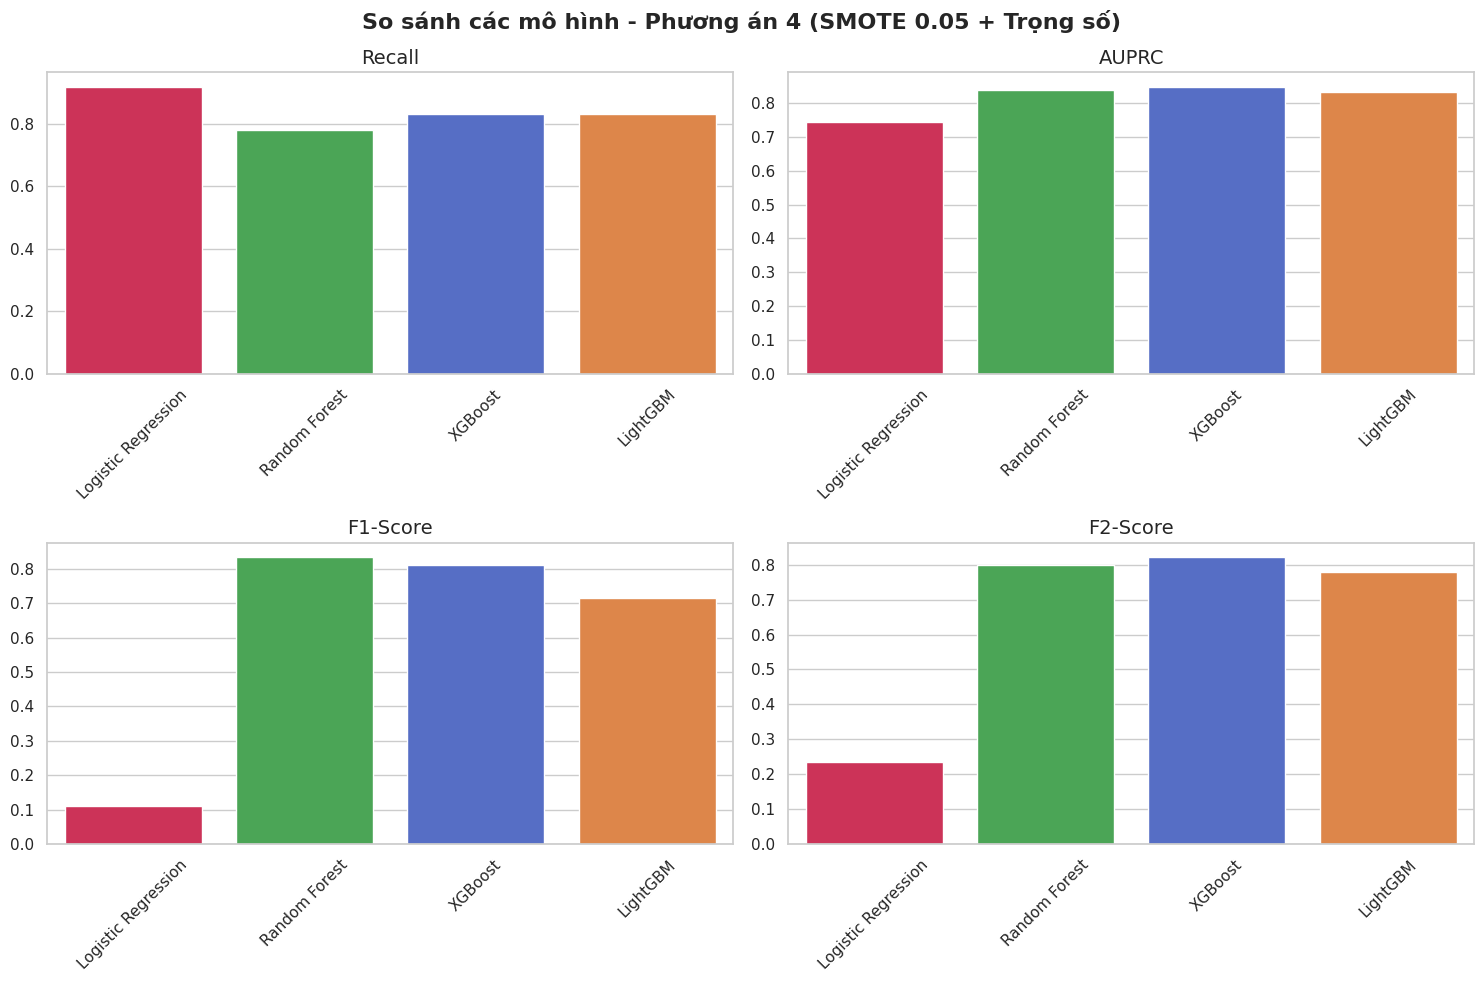

In [ ]:
models = list(results_kb4.keys())
recall_scores = [results_kb4[m]['Recall'] for m in models]
auprc_scores = [results_kb4[m]['AUPRC'] for m in models]
f1_scores = [results_kb4[m]['F1'] for m in models]
f2_scores = [results_kb4[m]['F2'] for m in models]

model_colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231']
palette = {m: model_colors[i] for i, m in enumerate(models)}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('So sánh các mô hình - Phương án 4 (SMOTE 0.05 + Trọng số)', fontsize=16, fontweight='bold')

# Vẽ Recall
sns.barplot(x=models, y=recall_scores, ax=axes[0, 0], palette=palette, hue=models, legend=False)
axes[0, 0].set_title('Recall', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Vẽ AUPRC
sns.barplot(x=models, y=auprc_scores, ax=axes[0, 1], palette=palette, hue=models, legend=False)
axes[0, 1].set_title('AUPRC', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# Vẽ F1-score
sns.barplot(x=models, y=f1_scores, ax=axes[1, 0], palette=palette, hue=models, legend=False)
axes[1, 0].set_title('F1-Score', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Vẽ F2-score
sns.barplot(x=models, y=f2_scores, ax=axes[1, 1], palette=palette, hue=models, legend=False)
axes[1, 1].set_title('F2-Score', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']

SCALE_POS_WEIGHT = y_train.value_counts()[0] / y_train.value_counts()[1]

PHƯƠNG ÁN 5: Focal Loss (trên dữ liệu gốc): Dùng cơ chế tập trung vào mẫu khó của Focal Loss trên dữ liệu cực kỳ mất cân bằng.

In [ ]:
import xgboost as xgb

xgb_focal = FocalXGB(alpha=0.9, gamma=1.25)
print(f"\nXGBoost Focal Loss (Alpha={xgb_focal.alpha}, Gamma={xgb_focal.gamma}):")
print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")
fold_metrics = []
for i, (train_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    # Huân luyện và dự báo
    xgb_focal.fit(X_tr, y_tr)
    proba = xgb_focal.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    # Tính toán các chỉ số
    metrics = [
        precision_score(y_val, pred, zero_division=0),
        recall_score(y_val, pred),
        f1_score(y_val, pred),
        fbeta_score(y_val, pred, beta=2), # F2-Score chuẩn
        average_precision_score(y_val, proba)
    ]
    fold_metrics.append(metrics)
    print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")
ans = np.mean(fold_metrics, axis=0)
print('-'*62)
print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")


XGBoost Focal Loss (Alpha=0.9, Gamma=1.25):
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.8889    | 0.8205   | 0.8533   | 0.8333   | 0.8635  
Fold 2  | 0.9403    | 0.7975   | 0.8630   | 0.8225   | 0.8315  
Fold 3  | 0.8767    | 0.8101   | 0.8421   | 0.8226   | 0.8432  
Fold 4  | 0.8193    | 0.8608   | 0.8395   | 0.8521   | 0.8680  
Fold 5  | 0.9265    | 0.7975   | 0.8571   | 0.8203   | 0.8332  
--------------------------------------------------------------
Average | 0.8903    | 0.8173   | 0.8510   | 0.8302   | 0.8478  



PHƯƠNG ÁN 6: Focal Loss + Undersampling (Tỉ lệ 0.5): Kết hợp giảm bớt "nhiễu" từ lớp 0 và dùng Focal Loss để bắt ca khó.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb

xgb_focal_hybrid = FocalXGB(alpha=0.9, gamma=2.0)
print(f"\nXGBoost Hybrid (Undersample 50% Class 0 + Focal Loss):")
print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")
fold_metrics = []

for i, (train_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    num_neg = np.sum(y_tr == 0)
    num_pos = np.sum(y_tr == 1)

    # Giảm lớp 0 xuống còn 50% số lượng mẫu ban đầu, giữ nguyên lớp 1
    target_strategies = {0: int(0.5 * num_neg), 1: int(num_pos)}
    rus = RandomUnderSampler(sampling_strategy=target_strategies, random_state=42)
    X_res, y_res = rus.fit_resample(X_tr, y_tr)

    xgb_focal_hybrid.fit(X_res, y_res)
    proba = xgb_focal_hybrid.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics = [
        precision_score(y_val, pred, zero_division=0),
        recall_score(y_val, pred),
        f1_score(y_val, pred),
        f2_score(y_val, pred),
        average_precision_score(y_val, proba)
    ]
    fold_metrics.append(metrics)
    print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

ans = np.mean(fold_metrics, axis=0)
print('-'*62)
print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")


XGBoost Hybrid (Undersample 50% Class 0 + Focal Loss):
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.7975    | 0.8077   | 0.8025   | 0.8056   | 0.8651  
Fold 2  | 0.8289    | 0.7975   | 0.8129   | 0.8036   | 0.8288  
Fold 3  | 0.7471    | 0.8228   | 0.7831   | 0.8065   | 0.8289  
Fold 4  | 0.7826    | 0.9114   | 0.8421   | 0.8824   | 0.8722  
Fold 5  | 0.7927    | 0.8228   | 0.8075   | 0.8166   | 0.8170  
--------------------------------------------------------------
Average | 0.7898    | 0.8324   | 0.8096   | 0.8229   | 0.8424  



PHƯƠNG ÁN 7: Ensemble methods: Kết hợp XGBoost và RandomForest.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
import xgboost as xgb
import numpy as np

base_estimators = [
    ('xgb_cw', XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT, random_state=42, n_jobs=-1, tree_method='hist')),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, max_samples=0.8, min_samples_leaf=5, random_state=42, n_jobs=-1))
]

ensembles = {
    'Soft Voting (XGB+RF)': VotingClassifier(estimators=base_estimators, voting='soft', n_jobs=-1),
    'Stacking (Meta: Logistic)': StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1, passthrough=False)
}

for name, model in ensembles.items():
    print(f"\n{name}:")
    print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")
    fold_metrics = []

    for i, (train_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        proba = m.predict_proba(X_val)[:, 1]
        pred  = (proba >= 0.5).astype(int)

        metrics = [
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred),
            f1_score(y_val, pred),
            f2_score(y_val, pred),
            average_precision_score(y_val, proba),
        ]
        fold_metrics.append(metrics)
        print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

    ans = np.mean(fold_metrics, axis=0)
    print('-' * 62)
    print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")


Soft Voting (XGB+RF):
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.9286    | 0.8333   | 0.8784   | 0.8508   | 0.8707  
Fold 2  | 0.9839    | 0.7722   | 0.8652   | 0.8069   | 0.8102  
Fold 3  | 0.9104    | 0.7722   | 0.8356   | 0.7963   | 0.8278  
Fold 4  | 0.8608    | 0.8608   | 0.8608   | 0.8608   | 0.8882  
Fold 5  | 0.9265    | 0.7975   | 0.8571   | 0.8203   | 0.8243  
--------------------------------------------------------------
Average | 0.9220    | 0.8072   | 0.8594   | 0.8270   | 0.8443  


Stacking (Meta: Logistic):
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.9385    | 0.7821   | 0.8531   | 0.8090   | 0.8716  
Fold 2  | 1.0000    | 0.7722   | 0.8714   | 0.8090   | 0.8114  
Fold 3  | 0.9231    | 0.7595   | 0.8333   | 0.7874   | 0.8299  
Fold 4  | 0.8816    | 0.8481   | 0.8645   | 0.8546   | 0.8890  
Fold 5  | 0.9683    | 0.7722   | 0.8592   | 0.8047   | 0.8258  
-----------------------------------------------------

PHƯƠNG ÁN 8: Sử dụng kỹ thuật Self-Ensemble kết hợp các Focal Loss có thiết lập Gamma khác nhau để nhận diện gian lận ở cả mức độ dễ nhận dạng và tinh vi

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, average_precision_score

focalEnsem = FocalEnsembleXGB(gamma_wide=1.0, gamma_deep=2.0, ensemble_weight=0.5)

print(f"\nSelf-Ensemble (XGB Focal Gamma {focalEnsem.gamma_wide} + XGB Focal Gamma {focalEnsem.gamma_deep}):")
print(f"{'Fold':<7} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8} | {'F2-score':<8} | {'AUPRC':<8}")

fold_metrics = []

for i, (train_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    focalEnsem.fit(X_tr, y_tr)
    proba = focalEnsem.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics = [
        precision_score(y_val, pred, zero_division=0),
        recall_score(y_val, pred),
        f1_score(y_val, pred),
        f2_score(y_val, pred),
        average_precision_score(y_val, proba)
    ]
    fold_metrics.append(metrics)
    print(f"Fold {i+1:<2} | {metrics[0]:<9.4f} | {metrics[1]:<8.4f} | {metrics[2]:<8.4f} | {metrics[3]:<8.4f} | {metrics[4]:<8.4f}")

ans = np.mean(fold_metrics, axis=0)
print('-'*62)
print(f"{'Average':<7} | {ans[0]:<9.4f} | {ans[1]:<8.4f} | {ans[2]:<8.4f} | {ans[3]:<8.4f} | {ans[4]:<8.4f}\n")


Self-Ensemble (XGB Focal Gamma 1.0 + XGB Focal Gamma 2.0):
Fold    | Precision | Recall   | F1-score | F2-score | AUPRC   
Fold 1  | 0.9375    | 0.7692   | 0.8451   | 0.7979   | 0.8820  
Fold 2  | 0.9831    | 0.7342   | 0.8406   | 0.7733   | 0.8084  
Fold 3  | 0.8841    | 0.7722   | 0.8243   | 0.7922   | 0.8207  
Fold 4  | 0.8684    | 0.8354   | 0.8516   | 0.8418   | 0.8407  
Fold 5  | 0.9545    | 0.7975   | 0.8690   | 0.8246   | 0.8409  
--------------------------------------------------------------
Average | 0.9255    | 0.7817   | 0.8461   | 0.8060   | 0.8385  



# Bước 3: Nhận xét và chọn ra 1 số model tốt để tối ưu hyperparameter và tuning threshold

In [ ]:
from sklearn.model_selection import StratifiedKFold
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']

SCALE_POS_WEIGHT = y_train.value_counts()[0] / y_train.value_counts()[1]

SMOTE (0.05) + Random Forest (Phương án 2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_smote_model = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.05, random_state=42)),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1))
])

param_dist_rf_pipeline = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 5],
    'model__max_samples': [0.3, 0.5, 0.7]
}

rf_smote_pipeline = AutoTunerCV(
    estimator=rf_smote_model,
    param_distributions=param_dist_rf_pipeline,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=10,
    random_state=42,
    n_jobs=-1
)
rf_smote_pipeline.fit(X_train, y_train)

summary_rfsmote = rf_smote_pipeline.get_params_summary()
print(f"Best Params (SMOTE + RF): {summary_rfsmote['best_params']}")
print(f"Best Threshold (SMOTE + RF): {summary_rfsmote['best_threshold']:.4f}")

Best Params (SMOTE + RF): {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_samples': 0.3, 'model__max_depth': 10}
Best Threshold (SMOTE + RF): 0.3367


LightGBM + Class Weight (Phương án 3)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=42,
    verbose=-1,
    n_estimators=100
)

param_distributions_lgbm = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, -1],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

lgbm_pipeline = AutoTunerCV(
    estimator=lgbm_model,
    param_distributions=param_distributions_lgbm,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

lgbm_pipeline.fit(X_train, y_train)

summary_lgbm = lgbm_pipeline.get_params_summary()
print(f"Tham số Tốt nhất (LightGBM CW): {summary_lgbm['best_params']}")
print(f"Ngưỡng chốt chặn Threshold (LightGBM CW): {summary_lgbm['best_threshold']:.4f}")

Tham số Tốt nhất (LightGBM CW): {'subsample': 0.9, 'num_leaves': 100, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Ngưỡng chốt chặn Threshold (LightGBM CW): 0.3618


XGBoost + Class Weight (Phương án 3)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=42,
    eval_metric='logloss',
    n_estimators=100
)

param_distributions_xgb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_pipeline_main = AutoTunerCV(
    estimator=xgb_model,
    param_distributions=param_distributions_xgb,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline_main.fit(X_train, y_train)

summary_xgb = xgb_pipeline_main.get_params_summary()
print(f"Tham số Tốt nhất (XGBoost CW): {summary_xgb['best_params']}")
print(f"Ngưỡng chốt chặn Threshold (XGBoost CW): {summary_xgb['best_threshold']:.4f}")

Tham số Tốt nhất (XGBoost CW): {'subsample': 0.8, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Ngưỡng chốt chặn Threshold (XGBoost CW): 0.3769


SMOTE (0.05) + XGBoost Class Weight (Phương án 4)

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_xgb_model = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.05, random_state=42)),
    ('model', XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT, random_state=42, eval_metric='logloss', n_estimators=100))
])

param_distributions_smote_xgb = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 10],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

smote_xgb_pipeline = AutoTunerCV(
    estimator=smote_xgb_model,
    param_distributions=param_distributions_smote_xgb,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

smote_xgb_pipeline.fit(X_train, y_train)

summary_smote_xgb = smote_xgb_pipeline.get_params_summary()
print(f"Tham số Tốt nhất (SMOTE + XGBoost): {summary_smote_xgb['best_params']}")
print(f"Ngưỡng chốt chặn Threshold (SMOTE + XGBoost): {summary_smote_xgb['best_threshold']:.4f}")

Tham số Tốt nhất (SMOTE + XGBoost): {'model__subsample': 1.0, 'model__max_depth': 10, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}
Ngưỡng chốt chặn Threshold (SMOTE + XGBoost): 0.3015


Focal Loss trên dữ liệu gốc (Phương án 5)

In [ ]:
base_focal_single = FocalXGB(n_estimators=100)

param_distributions_focal_single = {
    'gamma': [0.5, 1.0, 1.5, 2.0],
    'alpha': [0.75, 0.85, 0.9, 0.95],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

focal_single_pipeline = AutoTunerCV(
    estimator=base_focal_single,
    param_distributions=param_distributions_focal_single,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

focal_single_pipeline.fit(X_train, y_train)

summary_focal_single = focal_single_pipeline.get_params_summary()
print(f"Tham số Tốt nhất (Single Focal): {summary_focal_single['best_params']}")
print(f"Threshold tối ưu (Single Focal): {summary_focal_single['best_threshold']:.4f}")

Tham số Tốt nhất (Single Focal): {'max_depth': 5, 'learning_rate': 0.2, 'gamma': 1.0, 'alpha': 0.95}
Threshold tối ưu (Single Focal): 0.1709


Focal Loss + Undersampling với tỉ lệ 0.5 (Phương án 6)

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

focal_hybrid_model = ImbPipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('model', FocalXGB(n_estimators=100))
])

param_distributions_focal_hybrid = {
    'undersample__sampling_strategy': [0.1, 0.3, 0.5],
    'model__gamma': [1.0, 1.5, 2.0],
    'model__alpha': [0.75, 0.9],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1]
}

focal_hybrid_pipeline = AutoTunerCV(
    estimator=focal_hybrid_model,
    param_distributions=param_distributions_focal_hybrid,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

focal_hybrid_pipeline.fit(X_train, y_train)

summary_focal_hybrid = focal_hybrid_pipeline.get_params_summary()
print(f"Tham số Tốt nhất (Hybrid Focal): {summary_focal_hybrid['best_params']}")
print(f"Threshold tối ưu (Hybrid Focal): {summary_focal_hybrid['best_threshold']:.4f}")

Tham số Tốt nhất (Hybrid Focal): {'undersample__sampling_strategy': 0.1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 1.0, 'model__alpha': 0.75}
Threshold tối ưu (Hybrid Focal): 0.3769


Soft Voting Ensemble liên kết XGBoost và Random Forest (Phương án 7)



In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

xgb_base = XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT, random_state=42, eval_metric='logloss')
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

voting_model = VotingClassifier(
    estimators=[('xgb', xgb_base), ('rf', rf_base)],
    voting='soft',
    n_jobs=1
)

param_distributions_voting = {
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 15],
    'rf__max_samples': [0.6, 0.8, 1.0],
    'weights': [[1, 1], [2, 1], [1, 2]]
}

voting_pipeline = AutoTunerCV(
    estimator=voting_model,
    param_distributions=param_distributions_voting,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=10,
    random_state=42,
    n_jobs=-1
)

voting_pipeline.fit(X_train, y_train)

summary_voting = voting_pipeline.get_params_summary()
print(f"Tham số Tốt nhất (Voting XGB+RF): {summary_voting['best_params']}")
print(f"Ngưỡng chốt chặn Threshold (Voting XGB+RF): {summary_voting['best_threshold']:.4f}")

Tham số Tốt nhất (Voting XGB+RF): {'xgb__subsample': 0.8, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'weights': [1, 2], 'rf__n_estimators': 200, 'rf__max_samples': 0.6, 'rf__max_depth': 10}
Ngưỡng chốt chặn Threshold (Voting XGB+RF): 0.3367


Stacking Ensemble liên kết XGBoost và Random Forest (Phương án 7)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# TUNE BASE XGBOOST
xgb_base = XGBClassifier(scale_pos_weight=SCALE_POS_WEIGHT, random_state=42, eval_metric='logloss', n_estimators=100)

param_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb_pipeline_stacking = AutoTunerCV(
    estimator=xgb_base,
    param_distributions=param_xgb,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=5,
    random_state=42,
    n_jobs=-1
)
xgb_pipeline_stacking.fit(X_train, y_train)

best_xgb_params = xgb_pipeline_stacking.get_params_summary()['best_params']
print(f"-> Tham số Tốt nhất của XGBoost (Base): {best_xgb_params}\n")

xgb_best_model = XGBClassifier(
    scale_pos_weight=SCALE_POS_WEIGHT, random_state=42,
    eval_metric='logloss', n_estimators=100, **best_xgb_params
)

# TUNE BASE RANDOM FOREST
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

param_rf = {
    'n_estimators': [100, 1520. 150, 200],
    'max_depth': [8, 10, 15, 20, 25],
    'max_samples': [0.6, 0.8, 0.9]
}

rf_pipeline_stacking = AutoTunerCV(
    estimator=rf_base,
    param_distributions=param_rf,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=5,
    random_state=42,
    n_jobs=-1
)
rf_pipeline_stacking.fit(X_train, y_train)

best_rf_params = rf_pipeline_stacking.get_params_summary()['best_params']
print(f"-> Tham số Tốt nhất của Random Forest (Base): {best_rf_params}\n")

rf_best_model = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=1, **best_rf_params
)

# TUNE STACKING META-MODEL & THRESHOLD
meta_model = LogisticRegression(max_iter=1000, class_weight='balanced')

stacking_model = StackingClassifier(
    estimators=[('xgb', xgb_best_model), ('rf', rf_best_model)],
    final_estimator=meta_model,
    cv=2,
    n_jobs=-1
)
param_stacking = {
    'final_estimator__C': [0.01, 0.1, 1.0, 10.0],
    'final_estimator__penalty': ['l2']
}
stacking_pipeline = AutoTunerCV(
    estimator=stacking_model,
    param_distributions=param_stacking,
    n_splits=2,
    scoring='f2',
    threshold_metric='f1',
    n_iter=4,
    random_state=42,
    n_jobs=1
)
stacking_pipeline.fit(X_train, y_train)
summary_stacking = stacking_pipeline.get_params_summary()
print(f"\nTham số Hội tụ của Lõi Meta-Model (Stacking): {summary_stacking['best_params']}")
print(f"Ngưỡng chốt chặn Threshold Hội tụ Trấn phái (Stacking): {summary_stacking['best_threshold']:.4f}")

-> Tham số Tốt nhất của XGBoost (Base): {'subsample': 0.8, 'max_depth': 5, 'learning_rate': 0.05}

-> Tham số Tốt nhất của Random Forest (Base): {'n_estimators': 100, 'max_samples': 0.6, 'max_depth': 10}


Tham số Hội tụ của Lõi Meta-Model (Stacking): {'final_estimator__penalty': 'l2', 'final_estimator__C': 0.01}
Ngưỡng chốt chặn Threshold Hội tụ Trấn phái (Stacking): 0.2513


Self-Ensemble Focal Loss (Phương án 8)

In [ ]:
base_focal_ensemble = FocalEnsembleXGB(n_estimators=100)

param_distributions_focal = {
    'gamma_wide': [0.5, 1.0, 1.25, 1.5],
    'gamma_deep': [1.25, 1.5, 2.0, 2.5],
    'ensemble_weight': [0.2, 0.4, 0.5, 0.6],
    'max_depth': [3, 6, 8, 10, 12]
}

focal_ensemble_pipeline = AutoTunerCV(
    estimator=base_focal_ensemble,
    param_distributions=param_distributions_focal,
    n_splits=3,
    scoring='f2',
    threshold_metric='f1',
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

focal_ensemble_pipeline.fit(X_train, y_train)

summary_focal = focal_ensemble_pipeline.get_params_summary()
print(f"Tham số Tốt nhất (Self-Ensemble Focal Loss): {summary_focal['best_params']}")
print(f"Ngưỡng chốt chặn Threshold (Self-Ensemble Focal Loss): {summary_focal['best_threshold']:.4f}")

Tham số Tốt nhất (Self-Ensemble Focal Loss): {'max_depth': 6, 'gamma_wide': 1.0, 'gamma_deep': 1.25, 'ensemble_weight': 0.6}
Ngưỡng chốt chặn Threshold (Self-Ensemble Focal Loss): 0.4020


#### Tổng kết đánh giá trên tập test

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, average_precision_score, roc_auc_score
import pickle

final_tuned_models = {
    'LightGBM CW': lgbm_pipeline,
    'XGBoost CW': xgb_pipeline_main,
    'SMOTE (0.05) + XGBoost': smote_xgb_pipeline,
    'Single Focal Loss': focal_single_pipeline,
    'Hybrid Focal Loss': focal_hybrid_pipeline,
    'Soft Voting (XGB+RF)': voting_pipeline,
    'Stacking (Meta-LR)': stacking_pipeline,
    'SMOTE (0.05) + Random Forest': rf_smote_pipeline,
    'Self-Ensemble Focal Loss': focal_ensemble_pipeline
}

test_results = []

for name, pipeline in final_tuned_models.items():
    test_proba = pipeline.predict_proba(X_test)[:, 1]
    test_pred  = pipeline.predict(X_test)

    params_summary = pipeline.get_params_summary()
    best_thresh = params_summary['best_threshold']

    acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0)
    rec = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)
    f2 = fbeta_score(y_test, test_pred, beta=2)
    auprc = average_precision_score(y_test, test_proba)
    roc_auc = roc_auc_score(y_test, test_proba)

    test_results.append({
        'Tên Mô Hình': name,
        'Best Threshold': round(best_thresh, 4),
        'Accuracy': round(acc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'AUPRC': round(auprc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'F2-Score': round(f2, 4)
    })


if test_results:
    df_test = pd.DataFrame(test_results)
    df_test = df_test.sort_values(by='AUPRC', ascending=False).reset_index(drop=True)
    print(df_test.to_string(index=False))

                 Tên Mô Hình  Best Threshold  Accuracy  ROC-AUC  AUPRC  Precision  Recall  F1-Score  F2-Score
    Self-Ensemble Focal Loss          0.4020    0.9996   0.9751 0.8726     0.9222  0.8469    0.8830    0.8610
                  XGBoost CW          0.3769    0.9995   0.9820 0.8684     0.8804  0.8265    0.8526    0.8368
           Single Focal Loss          0.1709    0.9996   0.9775 0.8668     0.9011  0.8367    0.8677    0.8489
      SMOTE (0.05) + XGBoost          0.3015    0.9996   0.9766 0.8552     0.9506  0.7857    0.8603    0.8140
SMOTE (0.05) + Random Forest          0.3367    0.9993   0.9811 0.8281     0.7879  0.7959    0.7919    0.7943
        Soft Voting (XGB+RF)          0.3367    0.9993   0.9812 0.8001     0.7736  0.8367    0.8039    0.8233
                 LightGBM CW          0.3618    0.9992   0.9571 0.7480     0.8022  0.7449    0.7725    0.7557
           Hybrid Focal Loss          0.3769    0.9993   0.9722 0.7323     0.8085  0.7755    0.7917    0.7819
          

Kết luận

Dựa trên kết quả đánh giá toàn diện trên tập test, nhóm chọn **Self-Ensemble Focal Loss** là mô hình tốt nhất với các lý do sau:

1. **AUPRC cao nhất (0.8726)**: Chỉ số Area Under the Precision-Recall Curve là thước đo quan trọng nhất trong bài toán phát hiện gian lận với dữ liệu mất cân bằng. AUPRC = 0.8726 của Self-Ensemble Focal Loss vượt trội so với tất cả các phương án còn lại.

2. **F2-Score cao nhất (0.8610)**: F2-Score được ưu tiên vì nó trọng số hóa Recall cao hơn Precision, phù hợp với mục tiêu **không bỏ sót giao dịch gian lận** (giảm thiểu False Negative).

3. **Precision rất cao (0.9222)**: Độ chính xác cao giúp hạn chế cảnh báo nhầm (False Positive), tránh làm phiền khách hàng không cần thiết.

4. **Kiến trúc Self-Ensemble**: Mô hình kết hợp hai phiên bản Focal Loss XGBoost (gamma=1.0 và gamma=2.0) thông qua trung bình xác suất, tận dụng sức mạnh của ensemble learning để ổn định và cải thiện hiệu suất dự đoán.

=> **Mô hình được chọn**: focal_ensemble_pipeline — Self-Ensemble Focal Loss (gamma=1.0 + gamma=2.0, threshold=0.4020)

In [ ]:
# Đóng gói và tải model tốt nhất về để sử dụng

import pickle
import os
from google.colab import files

model = FocalEnsembleXGB(gamma_wide=1.0, gamma_deep=1.25, ensemble_weight=0.6, max_depth=6)
model.fit(X_train, y_train)

MODEL_FILENAME = 'model.pkl'
with open(MODEL_FILENAME, 'wb') as f:
    pickle.dump(model, f)
files.download(MODEL_FILENAME)

print("Đã tải model thành công.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đã tải model thành công.


## Bước 4: Sử dụng Model trong thực tế

Mô hình được phát triển thành một Hệ thống Quản lý Rủi ro Giao dịch hoàn chỉnh. Đây là 1 hệ thống quản trị nội bộ, giúp nhân viên ngân hàng có cái nhìn toàn cảnh về rủi ro mà khách hàng bên ngoài không thể can thiệp vào.
Hệ thống giải quyết triệt để 3 bài toán vận hành cốt lõi của ngân hàng:
- Lá chắn Real-time (Phòng ngừa tức thời): Kết nối trực tiếp với API từ Mobile/Web App. Hệ thống phản hồi chỉ trong milis giây, cho phép ngân hàng đóng băng giao dịch nghi vấn ngay lập tức, ngăn chặn thiệt hại tài chính trước khi nó xảy ra.
- Hệ thống Hỗ trợ Ra quyết định (Decision Support System): Không chỉ dừng lại ở kết quả Đúng/Sai, SafeGuard cung cấp Chỉ số rủi ro (Probability). Điều này giúp Chuyên viên Rủi ro (Risk Analyst) ưu tiên xử lý các trường hợp có độ nguy hiểm cao nhất, tối ưu hóa 80% thời gian kiểm soát thủ công.
- Xử lý Dữ liệu lớn (Scalability): Tính năng "Tải lên File" cho phép phòng đối soát dữ liệu quét hàng triệu giao dịch lịch sử trong phút chốc để tìm ra các mẫu tấn công gian lận có tổ chức tinh vi nhất.
- Ngoài ra, còn có Bảo mật dữ liệu (Privacy Preservation): Trong thực tế, các thông tin định danh cá nhân của khách hàng là cực kỳ nhạy cảm. Do đó, ngân hàng đã sử dụng thuật toán PCA (Principal Component Analysis) để biến đổi các thông tin thô này thành các thành phần chính (V1-V28). Quá trình này giúp mô hình vẫn học được quy luật gian lận nhưng không thể tra ngược lại được danh tính thật của khách hàng, đảm bảo tuân thủ các quy định về bảo mật tài chính.
#### Link web: https://kttt294-fraud-detection.streamlit.app
>
#### Giao diện web:
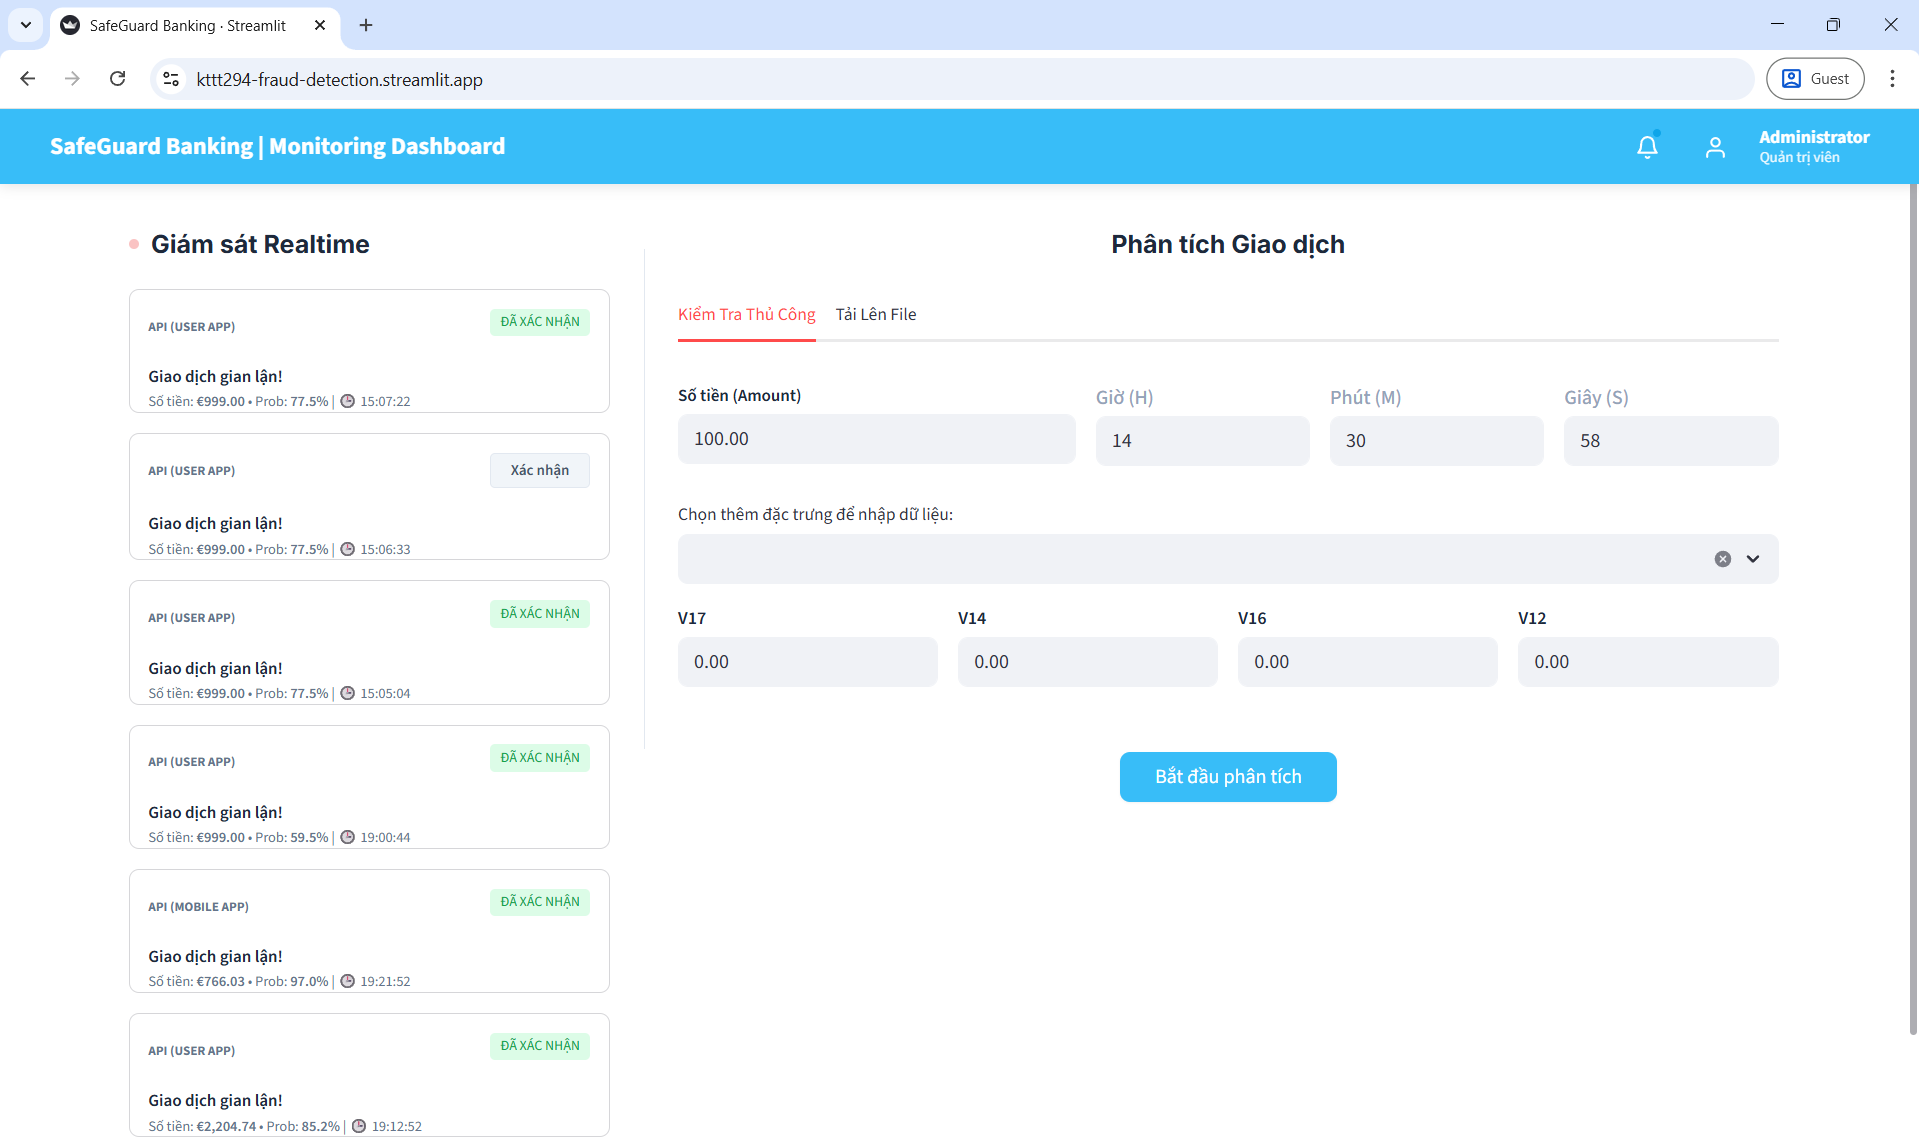

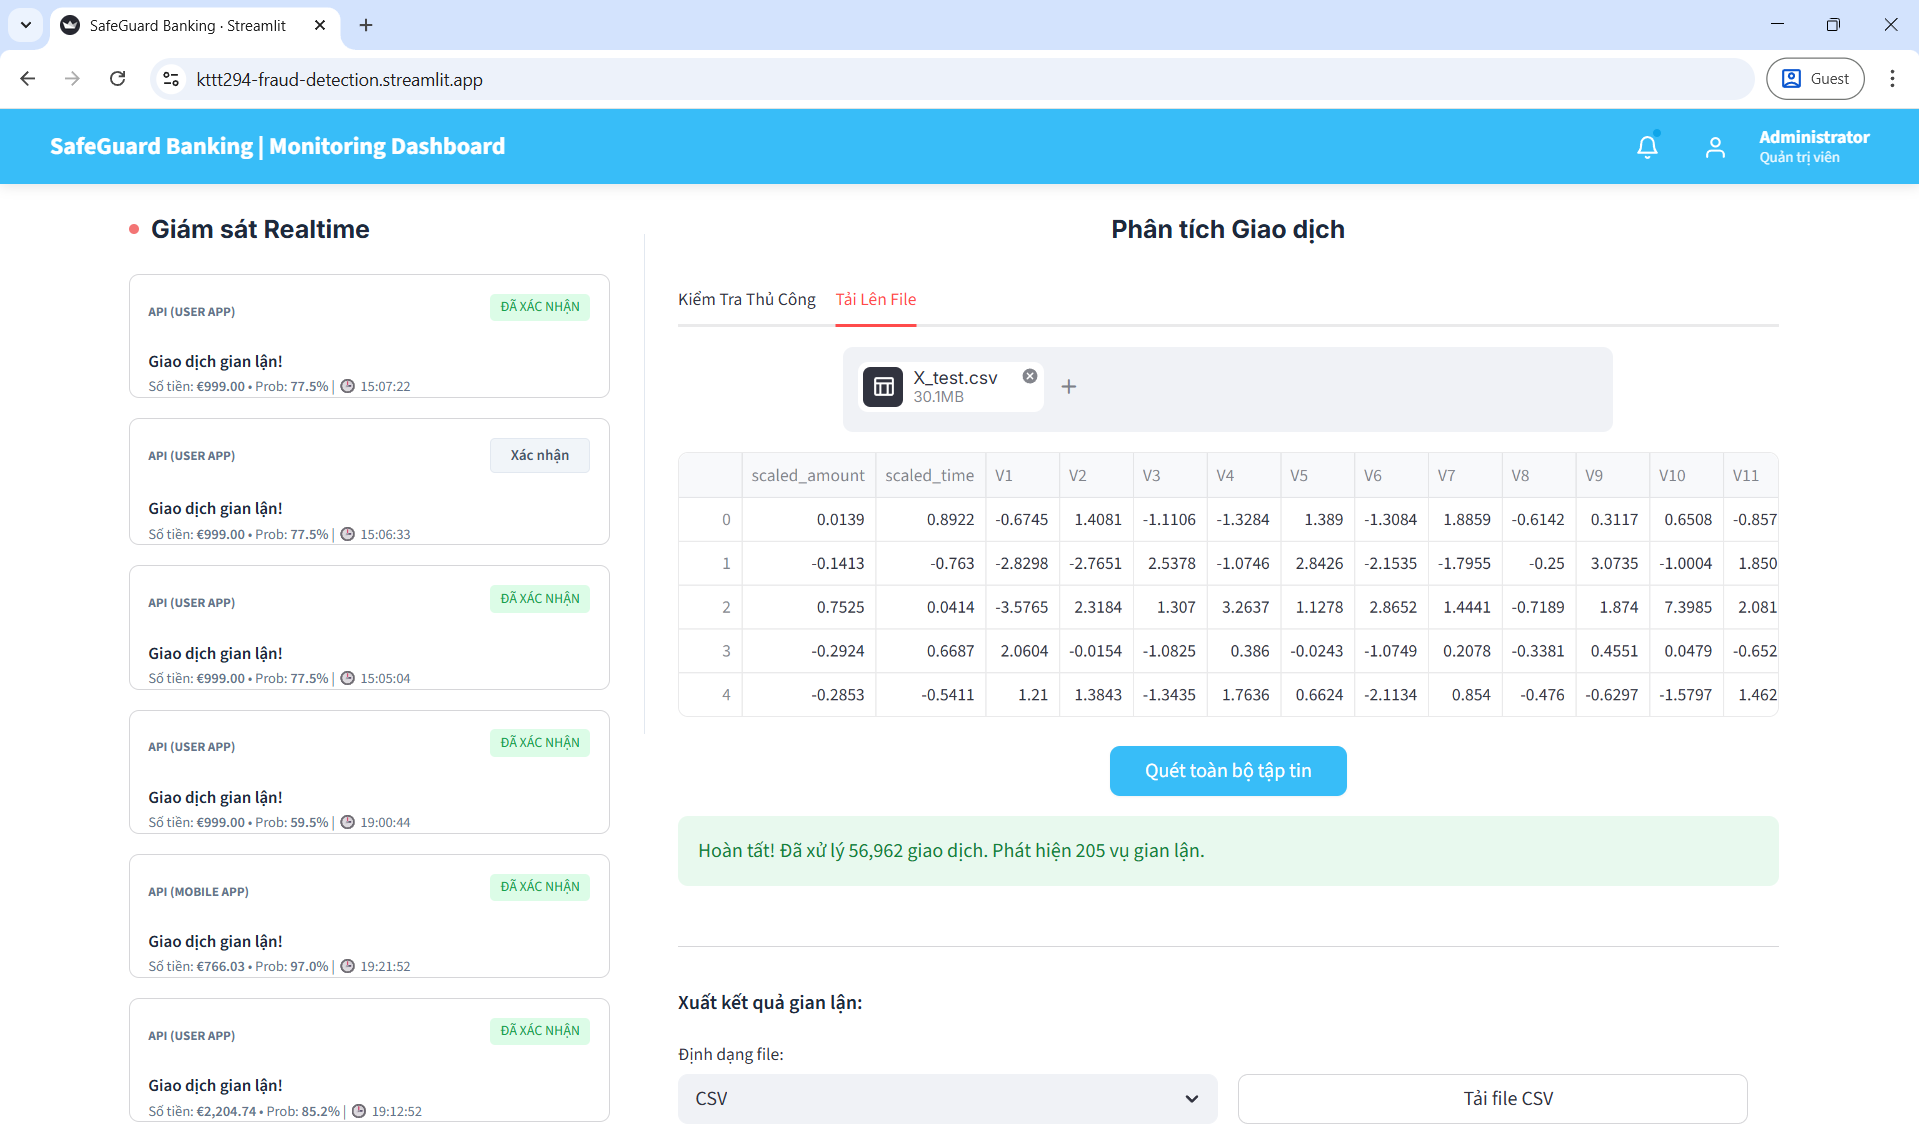